# AI-Driven Delivery Risk Prediction and Explainable Decision Support for Cross-Border E-Commerce Supply Chains

**Author:** Kiruthikaa Natarajan Srinivasan  
**Course:** 44688-80_MS Data Analytics Capstone  
**Instructor:** Ajay Bandi  
**Dataset:** Cross-Border E-Commerce Supply Chain Dataset  
**Date:** July 2026

## Project Objective

The objective of this project is to develop a machine learning system that predicts whether cross-border e-commerce shipments are likely to be delivered on time or delayed. The project will analyze operational, supplier, logistics, economic, and country-risk factors and use explainable artificial intelligence techniques to identify the main factors influencing delivery-risk predictions.

## 1. Project Introduction

Cross-border e-commerce supply chains involve multiple suppliers, transportation providers, ports, customs processes, currencies, and regulatory environments. These interconnected factors can increase the risk of shipment delays, which may affect customer satisfaction, inventory availability, operational costs, and overall supply-chain performance.

The purpose of this project is to develop an AI-driven delivery-risk prediction and explainable decision-support system for cross-border e-commerce supply chains. The analysis will use operational, supplier, logistics, economic, and country-risk attributes to predict whether a shipment is likely to be delivered on time or delayed.

In addition to generating predictions, the project will apply explainable AI techniques to identify the factors that contribute most strongly to delivery risk. These explanations can help supply-chain professionals understand model outcomes and make more informed decisions related to supplier management, logistics planning, and risk mitigation.


## 2. Import Required Libraries

The following libraries are imported to support data manipulation, visualization, preprocessing, machine learning, model evaluation, class-imbalance handling, explainable AI, and model storage. All required packages were installed in the project-specific virtual environment before running the notebook.

In [5]:
# Standard library imports
from pathlib import Path
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)

# Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine-learning models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

# Model-evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Class-imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Model explainability
import shap

# Model persistence
import joblib

## 3. Load the Dataset

This section loads the original cross-border e-commerce supply chain dataset from the `data/raw` folder. The raw dataset is preserved without modification, and a separate working copy is created for data inspection, cleaning, and analysis.

In [6]:
# Define the raw dataset location
data_path = Path("../data/raw/cross_border_ecommerce_supply_chain_dataset.csv")

# Use the project-root path if the notebook runs from the repository root
if not data_path.exists():
    data_path = Path("data/raw/cross_border_ecommerce_supply_chain_dataset.csv")

# Load the original dataset
df_raw = pd.read_csv(data_path)

# Create a working copy for analysis and cleaning
df = df_raw.copy()

print("Dataset loaded successfully.")
print(f"Source file: {data_path}")
print(f"Records: {df.shape[0]:,}")
print(f"Attributes: {df.shape[1]}")

Dataset loaded successfully.
Source file: ..\data\raw\cross_border_ecommerce_supply_chain_dataset.csv
Records: 25,000
Attributes: 43


#### 3.1 Data Loading Observations

The dataset loaded successfully from the `data/raw` directory. It contains **25,000 records and 43 attributes**. A separate working copy was created so that the original dataset remains unchanged during the cleaning and analysis process.

## 4. Initial Data Inspection

Before cleaning the dataset, an initial inspection is performed to understand its structure and contents. This includes reviewing sample records, column names, data types, completeness, and summary statistics. The findings from this inspection will guide the data-cleaning decisions in the next section.

### 4.1 Preview the Dataset

The first ten records are displayed to examine how the attributes and values are organized.

In [7]:
# Display the first ten records
df.head(10)

,Order_ID,Date,Week,Month,Year,Product_ID,Product_Category,Brand,Region,Country,...,Shipping_Mode,Shipping_Cost,Carbon_Emission,Delivery_Time_OnTime,Service_Level,Total_Logistics_Cost,Stockout_Flag,Demand_Next_Period,Optimal_Replenishment_Qty,Best_Warehouse_Choice
0,1,10/16/2024,42,10,2024,P5506,Fashion,Brand_B,North America,USA,...,Ground,263.566325,196.503459,0,84.044030,7469.570907,0,105,0,WH_3
1,2,7/12/2024,28,7,2024,P7912,Electronics,Brand_A,North America,Mexico,...,Air,616.362481,547.328235,0,75.816559,3713.919436,0,234,0,WH_4
2,3,6/1/2024,22,6,2024,P4257,Sports,Brand_D,Latin America,Brazil,...,Ground,294.408705,345.107134,0,86.952456,17305.637690,0,326,817,WH_3
3,4,10/12/2023,41,10,2023,P7924,Home,Brand_C,North America,USA,...,Sea,94.328223,62.270461,1,95.013599,4948.720754,0,104,0,WH_3
4,5,4/15/2023,15,4,2023,P2584,Home,Brand_C,North America,Canada,...,Ground,303.197646,252.221897,1,93.697310,2390.449398,0,283,0,WH_4
5,6,4/15/2024,16,4,2024,P7201,Electronics,Brand_E,Latin America,Brazil,...,Ground,256.596783,188.323770,0,76.475660,4195.193854,0,257,0,WH_3
6,7,7/16/2023,28,7,2023,P4733,Home,Brand_A,North America,USA,...,Sea,159.983973,121.304093,1,99.003372,4427.708482,0,314,0,WH_3
7,8,10/12/2023,41,10,2023,P3664,Home,Brand_C,Middle East,Saudi Arabia,...,Ground,175.961329,83.923214,0,82.228888,8910.199102,0,238,0,WH_3
8,9,11/30/2024,48,11,2024,P3803,Sports,Brand_B,North America,Mexico,...,Sea,105.739058,103.705119,0,89.147470,10759.246580,0,194,0,WH_3
9,10,10/4/2023,40,10,2023,P6313,Electronics,Brand_B,Latin America,Brazil,...,Sea,223.634901,218.435823,0,88.676954,6852.089303,0,159,0,WH_4


#### 4.1 Dataset Preview Observations

The preview confirms that the dataset contains a combination of identifier, date, categorical, numeric, operational, logistics, and outcome-related attributes. Examples include `Order_ID`, `Date`, `Product_Category`, `Region`, `Country`, `Shipping_Mode`, `Shipping_Cost`, `Delivery_Time_OnTime`, and `Stockout_Flag`.

The records appear to be organized consistently, but a more detailed review is required to confirm data types, missing values, duplicate records, and possible data-quality issues.

### 4.2 Review Dataset Structure and Data Types

This step reviews the dataset dimensions, column names, data types, and non-null counts. The results help identify whether any attributes require data-type conversion or further completeness checks before cleaning.

In [8]:
# Review the dataset structure and data types
print(f"Dataset shape: {df.shape[0]:,} records and {df.shape[1]} attributes\n")

df.info()

Dataset shape: 25,000 records and 43 attributes

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order_ID                   25000 non-null  int64  
 1   Date                       25000 non-null  str    
 2   Week                       25000 non-null  int64  
 3   Month                      25000 non-null  int64  
 4   Year                       25000 non-null  int64  
 5   Product_ID                 25000 non-null  str    
 6   Product_Category           25000 non-null  str    
 7   Brand                      25000 non-null  str    
 8   Region                     25000 non-null  str    
 9   Country                    25000 non-null  str    
 10  Customer_Segment           25000 non-null  str    
 11  Marketing_Spend            25000 non-null  float64
 12  Discount_Rate              25000 non-null  float64
 13  Product_

#### 4.2 Dataset Structure and Data-Type Observations

The dataset contains **25,000 records and 43 attributes**. All attributes contain 25,000 non-null values, so no visible missing values were identified during this structural review.

The dataset includes:

- **18 floating-point attributes**
- **15 integer attributes**
- **10 string attributes**

Most attributes appear to have appropriate data types. However, the `Date` attribute is currently stored as a string and should be converted to a datetime format during data cleaning. Identifier fields such as `Order_ID` and `Product_ID` will also need to be distinguished from predictive features before model development.

### 4.3 Check for Missing and Hidden Missing Values

This step checks the dataset for both standard missing values and hidden missing-value representations. Standard missing values may appear as null values, while hidden missing values can appear as blank strings or placeholders such as `NA`, `N/A`, `None`, `Null`, or `?`.

In [9]:
# Check standard missing values
missing_values = df.isna().sum()
missing_summary = missing_values[missing_values > 0]

print("Standard missing values:")
if missing_summary.empty:
    print("No standard missing values were found.")
else:
    print(missing_summary)

# Check blank strings in text columns
text_columns = df.select_dtypes(include="str").columns

blank_counts = {
    column: df[column].str.strip().eq("").sum()
    for column in text_columns
}

blank_counts = {
    column: count
    for column, count in blank_counts.items()
    if count > 0
}

print("\nBlank-string values:")
if not blank_counts:
    print("No blank-string values were found.")
else:
    print(blank_counts)

# Check common placeholder values in text columns
missing_placeholders = {"NA", "N/A", "NONE", "NULL", "NAN", "?", "-"}

placeholder_counts = {}

for column in text_columns:
    normalized_values = df[column].str.strip().str.upper()
    counts = normalized_values[
        normalized_values.isin(missing_placeholders)
    ].value_counts()

    if not counts.empty:
        placeholder_counts[column] = counts.to_dict()

print("\nMissing-value placeholders:")
if not placeholder_counts:
    print("No common missing-value placeholders were found.")
else:
    print(placeholder_counts)

Standard missing values:
No standard missing values were found.

Blank-string values:
No blank-string values were found.

Missing-value placeholders:
No common missing-value placeholders were found.


#### 4.3 Missing-Value Assessment Observations

No standard missing values, blank strings, or common missing-value placeholders were found in the dataset. Therefore, no records or attributes need to be removed, and no imputation strategy is required at this stage.

Retaining the original values is preferable because unnecessary imputation could introduce artificial information and alter the dataset’s natural distribution. 

### 4.4 Check for Duplicate Records

This step checks for exact duplicate rows and repeated `Order_ID` values. Exact duplicates may indicate duplicated records, while repeated order identifiers could indicate either a data-quality issue or multiple records associated with the same order.

In [10]:
# Check for exact duplicate rows
exact_duplicate_count = df.duplicated().sum()

# Check whether Order_ID values are unique
duplicate_order_id_count = df["Order_ID"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Duplicate Order_ID values: {duplicate_order_id_count}")

Exact duplicate rows: 0
Duplicate Order_ID values: 0


#### 4.4 Duplicate Record Assessment Observations

No exact duplicate rows were identified, and every `Order_ID` is unique. Therefore, no records need to be removed due to duplication, and the dataset retains all **25,000 records**.

### 4.5 Review Categorical Values for Consistency

This step reviews the string-based attributes to identify inconsistent capitalization, extra spaces, spelling variations, unexpected categories, or unusually high numbers of unique values. These checks help determine whether categorical values require standardization before analysis.

In [11]:
# Identify text-based attributes
text_columns = df.select_dtypes(include="str").columns

# Summarize unique values and sample categories
categorical_summary = pd.DataFrame({
    "Attribute": text_columns,
    "Unique_Count": [df[column].nunique() for column in text_columns],
    "Sample_Values": [
        ", ".join(
            sorted(df[column].dropna().astype(str).str.strip().unique())[:10]
        )
        for column in text_columns
    ],
})

categorical_summary

,Attribute,Unique_Count,Sample_Values
0,Date,730,"1/1/2023, 1/1/2024, 1/10/2023, 1/10/2024, 1/11..."
1,Product_ID,8446,"P1000, P1001, P1002, P1003, P1004, P1005, P100..."
2,Product_Category,5,"Beauty, Electronics, Fashion, Home, Sports"
3,Brand,5,"Brand_A, Brand_B, Brand_C, Brand_D, Brand_E"
4,Region,5,"Asia Pacific, Europe, Latin America, Middle Ea..."
5,Country,15,"Brazil, Canada, Chile, China, France, Germany,..."
6,Customer_Segment,2,"Retail, Wholesale"
7,Warehouse_ID,4,"WH_1, WH_2, WH_3, WH_4"
8,Shipping_Mode,3,"Air, Ground, Sea"
9,Best_Warehouse_Choice,4,"WH_1, WH_2, WH_3, WH_4"


#### 4.5 Categorical Value Consistency Observations

The categorical attributes appear to be consistently formatted, with no visible capitalization differences, extra spaces, or duplicate category labels.

The dataset contains:

- 5 product categories
- 5 brands
- 5 geographic regions
- 15 countries
- 2 customer segments
- 4 warehouse identifiers
- 3 shipping modes
- 4 recommended warehouse choices

`Product_ID` contains **8,446 unique values** and functions as an identifier rather than a standard categorical predictor. The `Date` attribute contains **730 unique values** and should be converted from text to datetime format during cleaning rather than treated as a categorical variable.

No categorical value corrections are required based on this review.

### 4.6 Review Numeric Attributes and Value Ranges

This step reviews the minimum, maximum, mean, and median values of numeric attributes. The purpose is to identify impossible negative values, unexpected ranges, or other numeric inconsistencies that may require correction during data cleaning.

In [12]:
# Identify numeric attributes
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Summarize numeric value ranges
numeric_summary = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
}).round(3)

numeric_summary

,Minimum,Maximum,Mean,Median
Order_ID,1.000,25000.000,12500.500,12500.500
Week,1.000,52.000,26.487,27.000
Month,1.000,12.000,6.509,7.000
Year,2023.000,2024.000,2023.500,2023.000
Marketing_Spend,500.427,9998.880,5262.447,5274.325
Discount_Rate,0.000,0.400,0.200,0.201
Product_Price,10.039,499.981,255.933,257.673
Competitor_Price,9.309,548.665,256.111,257.192
Website_Traffic,1002.000,49998.000,25665.800,25623.000
Conversion_Rate,0.010,0.200,0.105,0.105


#### 4.6 Numeric Attribute and Range Observations

The numeric attributes show no obvious impossible negative values. Calendar fields fall within expected ranges, with weeks from 1 to 52, months from 1 to 12, and years limited to 2023 and 2024.

The binary attributes `Festival_Season`, `Delivery_Time_OnTime`, and `Stockout_Flag` are correctly represented using 0 and 1. Other operational attributes, including `Lead_Time_Days`, `Supplier_Reliability`, `Tariff_Rate`, `Inventory_Level`, and `Warehouse_Capacity`, also appear to fall within reasonable ranges.

Some variables, including `Shipping_Cost`, `Carbon_Emission`, `Total_Logistics_Cost`, and `Optimal_Replenishment_Qty`, have means noticeably higher than their medians. This suggests possible right-skewed distributions or valid high-value observations. These values should not be removed automatically and will be examined further during exploratory analysis.

`Order_ID` is a unique identifier and should not be treated as a numeric predictor during model development. Based on this initial range review, no numeric values require correction or removal at this stage.

### 4.7 Validate the Date Attribute

The `Date` attribute is currently stored as text. This step verifies whether all date values can be converted successfully to a datetime format and checks whether the extracted month and year are consistent with the existing `Month` and `Year` attributes.

In [13]:
# Convert the Date attribute temporarily for validation
parsed_dates = pd.to_datetime(df["Date"], errors="coerce")

# Count values that could not be converted
invalid_date_count = parsed_dates.isna().sum()

# Compare parsed month and year with the existing calendar attributes
month_mismatch_count = (parsed_dates.dt.month != df["Month"]).sum()
year_mismatch_count = (parsed_dates.dt.year != df["Year"]).sum()

print(f"Invalid or unparseable dates: {invalid_date_count}")
print(f"Month mismatches: {month_mismatch_count}")
print(f"Year mismatches: {year_mismatch_count}")
print(f"Date range: {parsed_dates.min().date()} to {parsed_dates.max().date()}")

Invalid or unparseable dates: 0
Month mismatches: 0
Year mismatches: 0
Date range: 2023-01-01 to 2024-12-30


#### 4.7 Date Validation Observations

All **25,000 date values** were successfully parsed, with no invalid or unrecognizable dates identified. The extracted month and year values also matched the existing `Month` and `Year` attributes for every record.

The dataset covers the period from **January 1, 2023, through December 30, 2024**. Because the date values are valid and internally consistent, the `Date` attribute can be safely converted from string format to datetime format during data cleaning.

## 5. Data Cleaning

The data-quality assessment found no missing values, hidden placeholders, duplicate records, inconsistent categorical labels, or invalid numeric ranges. Therefore, the cleaning process focuses on correcting the `Date` data type and standardizing text fields without deleting records or attributes.

### 5.1 Apply Data-Cleaning Actions

A cleaned copy of the dataset is created so that the original working data remains available for comparison. The `Date` attribute is converted from text to datetime format, and leading or trailing spaces are removed from all text-based attributes as a preventive standardization step.

In [14]:
# Create a cleaned copy of the dataset
df_clean = df.copy()

# Convert the Date attribute from string to datetime
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

# Remove leading and trailing spaces from text attributes
text_columns = df_clean.select_dtypes(include="str").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Confirm the cleaning results
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Date data type after cleaning: {df_clean['Date'].dtype}")
print(f"Missing values after cleaning: {df_clean.isna().sum().sum()}")
print(f"Duplicate rows after cleaning: {df_clean.duplicated().sum()}")

Original shape: (25000, 43)
Cleaned shape: (25000, 43)
Date data type after cleaning: datetime64[us]
Missing values after cleaning: 0
Duplicate rows after cleaning: 0


#### 5.1 Data-Cleaning Results and Observations

The cleaning process retained all **25,000 records and 43 attributes**. No rows or columns were removed because the dataset contained no missing values, duplicate records, or invalid values requiring deletion.

The `Date` attribute was successfully converted from string format to `datetime64`, making it suitable for time-based analysis. Text attributes were also standardized by removing any leading or trailing spaces.

After cleaning, the dataset contains:

- **25,000 records**
- **43 attributes**
- **0 missing values**
- **0 duplicate records**

The cleaned dataset is therefore complete and ready for variable definition and later preprocessing.

## 6. Define Dependent and Independent Variables

This section identifies the outcome the project is designed to predict and the attributes that may be used as predictors. Identifier fields, alternative outcomes, and attributes that may reveal information unavailable before delivery will be evaluated separately to reduce the risk of data leakage.

### 6.1 Review the Dependent Variable

The primary dependent variable is `Delivery_Time_OnTime`. This binary attribute represents whether an order was delivered on time. Its values and class distribution are reviewed to confirm the target encoding and determine whether the outcome classes are balanced.

In [15]:
# Review the values and distribution of the dependent variable
target_counts = df_clean["Delivery_Time_OnTime"].value_counts().sort_index()
target_percentages = (
    df_clean["Delivery_Time_OnTime"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Record_Count": target_counts,
    "Percentage": target_percentages,
})

target_summary.index.name = "Delivery_Time_OnTime"
target_summary

,Record_Count,Percentage
Delivery_Time_OnTime,,
0,19278,77.11
1,5722,22.89


#### 6.1 Dependent Variable Observations

The dependent variable `Delivery_Time_OnTime` contains two classes:

- **0:** 19,278 records (**77.11%**)
- **1:** 5,722 records (**22.89%**)

Based on the attribute name, the value **1** is interpreted as an on-time delivery, while **0** represents a delivery that was not on time. This encoding should also be confirmed against the dataset documentation before model development.

The class distribution is imbalanced because approximately three-quarters of the records belong to class 0. Therefore, accuracy alone may not be sufficient for evaluating future models. Metrics such as precision, recall, F1-score, ROC-AUC, and precision-recall AUC should also be considered. Class-weighting or resampling methods may be evaluated later during model development, but no balancing technique is applied during data cleaning.

### 6.2 Define Important Attributes and Candidate Independent Variables

The independent variables are the attributes that may help predict whether an order will be delivered on time. Identifier fields, the raw date field, alternative outcomes, and attributes that may contain information produced after delivery are excluded from the initial predictor set to reduce redundancy and potential data leakage.

The exclusions are based on the attribute names and the current prediction objective. These decisions will be reviewed again against the dataset documentation before model development.

In [16]:
# Define the dependent variable
target_column = "Delivery_Time_OnTime"

# Identifier attributes are retained for traceability but excluded from modeling
identifier_columns = [
    "Order_ID",
    "Product_ID",
]

# The raw date is retained, while Week, Month, and Year may be used as predictors
date_columns_excluded = [
    "Date",
]

# Alternative outcomes, optimization outputs, or possible post-delivery attributes
possible_leakage_columns = [
    "Service_Level",
    "Total_Logistics_Cost",
    "Stockout_Flag",
    "Demand_Next_Period",
    "Optimal_Replenishment_Qty",
    "Best_Warehouse_Choice",
]

# Create the candidate independent-variable list
excluded_columns = (
    [target_column]
    + identifier_columns
    + date_columns_excluded
    + possible_leakage_columns
)

independent_variables = [
    column
    for column in df_clean.columns
    if column not in excluded_columns
]

print(f"Dependent variable: {target_column}")
print(f"Number of candidate independent variables: {len(independent_variables)}")
print("\nCandidate independent variables:")

for column in independent_variables:
    print(f"- {column}")

Dependent variable: Delivery_Time_OnTime
Number of candidate independent variables: 33

Candidate independent variables:
- Week
- Month
- Year
- Product_Category
- Brand
- Region
- Country
- Customer_Segment
- Marketing_Spend
- Discount_Rate
- Product_Price
- Competitor_Price
- Website_Traffic
- Conversion_Rate
- Search_Trend_Index
- Festival_Season
- Weather_Index
- Currency_Exchange_Rate
- Tariff_Rate
- Fuel_Cost_Index
- Port_Congestion_Index
- Lead_Time_Days
- Supplier_Reliability
- Return_Rate
- Historical_Sales
- Inventory_Level
- Safety_Stock
- Warehouse_ID
- Warehouse_Capacity
- Distance_to_Customer
- Shipping_Mode
- Shipping_Cost
- Carbon_Emission


#### 6.2 Independent Variable Selection Observations

The analysis identified **33 candidate independent variables** that may contribute to predicting `Delivery_Time_OnTime`. These variables represent several dimensions of the cross-border supply chain, including:

- Time-related factors such as `Week`, `Month`, and `Year`
- Product and market characteristics such as `Product_Category`, `Brand`, `Product_Price`, and `Marketing_Spend`
- Geographic factors such as `Region` and `Country`
- External-risk factors such as `Weather_Index`, `Currency_Exchange_Rate`, `Tariff_Rate`, `Fuel_Cost_Index`, and `Port_Congestion_Index`
- Supplier and inventory factors such as `Supplier_Reliability`, `Inventory_Level`, and `Safety_Stock`
- Logistics factors such as `Lead_Time_Days`, `Distance_to_Customer`, `Shipping_Mode`, `Shipping_Cost`, and `Carbon_Emission`

`Order_ID` and `Product_ID` were excluded because they function as identifiers rather than meaningful predictive attributes. The original `Date` field was also excluded because its time-related information is already represented through `Week`, `Month`, and `Year`.

Attributes classified as possible post-outcome, optimization, or alternative-result variables were excluded from the initial predictor set to reduce the risk of data leakage. These exclusions will be reviewed again before model development based on the exact timing and definition of each attribute.

### 6.3 Define Important Data Attributes

The following attributes are especially relevant to the delivery-risk prediction problem. Their definitions clarify how operational, supplier, geographic, economic, and logistics factors are represented in the dataset.

In [18]:
# Define important attributes related to the delivery-risk problem
important_attributes = pd.DataFrame({
    "Attribute": [
        "Delivery_Time_OnTime",
        "Lead_Time_Days",
        "Supplier_Reliability",
        "Port_Congestion_Index",
        "Shipping_Mode",
        "Distance_to_Customer",
        "Shipping_Cost",
        "Tariff_Rate",
        "Currency_Exchange_Rate",
        "Inventory_Level",
        "Safety_Stock",
        "Weather_Index",
    ],
    "Definition": [
        "Binary dependent variable indicating whether an order was delivered on time.",
        "Number of days required to complete the supply or delivery process.",
        "Measure of the supplier's consistency and dependability.",
        "Measure of congestion affecting port operations and shipment movement.",
        "Transportation method used for delivery, such as air, ground, or sea.",
        "Distance between the warehouse and the customer.",
        "Cost associated with transporting the order.",
        "Tariff percentage associated with cross-border trade.",
        "Exchange-rate measure representing international currency conditions.",
        "Quantity of inventory available for fulfilling demand.",
        "Additional inventory maintained to protect against uncertainty.",
        "Index representing weather conditions that may influence logistics operations.",
    ],
    "Role": [
        "Dependent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
        "Independent variable",
    ],
})

important_attributes

,Attribute,Definition,Role
0,Delivery_Time_OnTime,Binary dependent variable indicating whether a...,Dependent variable
1,Lead_Time_Days,Number of days required to complete the supply...,Independent variable
2,Supplier_Reliability,Measure of the supplier's consistency and depe...,Independent variable
3,Port_Congestion_Index,Measure of congestion affecting port operation...,Independent variable
4,Shipping_Mode,"Transportation method used for delivery, such ...",Independent variable
5,Distance_to_Customer,Distance between the warehouse and the customer.,Independent variable
6,Shipping_Cost,Cost associated with transporting the order.,Independent variable
7,Tariff_Rate,Tariff percentage associated with cross-border...,Independent variable
8,Currency_Exchange_Rate,Exchange-rate measure representing internation...,Independent variable
9,Inventory_Level,Quantity of inventory available for fulfilling...,Independent variable


## 7. Save the Cleaned Dataset

The cleaned dataset is saved separately in the `data/processed` folder. This preserves the original raw file while creating a validated dataset for future exploratory analysis, preprocessing, and predictive modeling.

In [17]:
# Define the cleaned dataset location
cleaned_data_path = Path(
    "../data/processed/cross_border_ecommerce_supply_chain_cleaned.csv"
)

# Use the project-root path if the notebook runs from the repository root
if not cleaned_data_path.parent.exists():
    cleaned_data_path = Path(
        "data/processed/cross_border_ecommerce_supply_chain_cleaned.csv"
    )

# Create the processed-data folder if needed
cleaned_data_path.parent.mkdir(parents=True, exist_ok=True)

# Save the cleaned dataset
df_clean.to_csv(cleaned_data_path, index=False)

print("Cleaned dataset saved successfully.")
print(f"Output file: {cleaned_data_path}")
print(f"Final records: {df_clean.shape[0]:,}")
print(f"Final attributes: {df_clean.shape[1]}")

Cleaned dataset saved successfully.
Output file: ..\data\processed\cross_border_ecommerce_supply_chain_cleaned.csv
Final records: 25,000
Final attributes: 43


## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted on the cleaned cross-border 
e-commerce supply chain dataset to identify distributions, patterns, relationships, 
class imbalance, and potential anomalies before predictive model development.

The findings from this phase will guide feature preparation, model selection, 
class-imbalance handling, and model evaluation.

### 8.1 Prepare the Dataset for Exploratory Analysis

A separate EDA dataframe is created from the cleaned dataset so that the validated 
data remains unchanged. Readable labels are also assigned to the binary delivery 
outcome for clearer interpretation in tables and visualizations.

In [32]:
# Create a separate dataframe for exploratory analysis
df_eda = df_clean.copy()

# Confirm the dependent variable
target_column = "Delivery_Time_OnTime"

# Create readable labels for the delivery outcome
delivery_labels = {
    0: "Delayed",
    1: "On Time",
}

df_eda["Delivery_Status"] = (
    df_eda[target_column]
    .map(delivery_labels)
)

# Apply a consistent visualization theme
sns.set_theme(
    style="whitegrid",
    context="notebook",
)

# Define colors for the delivery outcomes
delivery_palette = {
    "Delayed": "#E76F51",
    "On Time": "#2A9D8F",
}

print("EDA dataframe prepared successfully.")
print(f"Records available for EDA: {df_eda.shape[0]:,}")
print(f"Attributes available for EDA: {df_eda.shape[1]}")
print("\nDelivery-status labels:")
print(df_eda["Delivery_Status"].value_counts())

EDA dataframe prepared successfully.
Records available for EDA: 25,000
Attributes available for EDA: 44

Delivery-status labels:
Delivery_Status
Delayed    19278
On Time     5722
Name: count, dtype: int64


#### Observation – EDA Dataset Preparation

The cleaned dataset was successfully copied into a separate dataframe for 
exploratory analysis. The EDA dataframe contains **25,000 records and 44 
attributes**.

The original cleaned dataset contained 43 attributes. The additional attribute, 
`Delivery_Status`, was created by converting the binary target values into the 
readable labels `Delayed` and `On Time`.

The delivery-status distribution contains **19,278 delayed orders** and **5,722 
on-time orders**. No records were added or removed during this preparation step. 
The additional column was created only to improve the readability of tables and 
visualizations, while the original binary target variable was retained for later 
predictive modeling.

### 8.2 Target-Variable Distribution

The distribution of the dependent variable, `Delivery_Time_OnTime`, is examined 
to compare delayed and on-time deliveries.

A bar chart is used to show both the number and percentage of records in each 
delivery-outcome class. This analysis helps determine whether the target variable 
is balanced before predictive modeling.

,Delivery_Status,Record_Count,Percentage
0,Delayed,19278,77.11
1,On Time,5722,22.89


Chart saved to: ..\outputs\figures\target_distribution.png


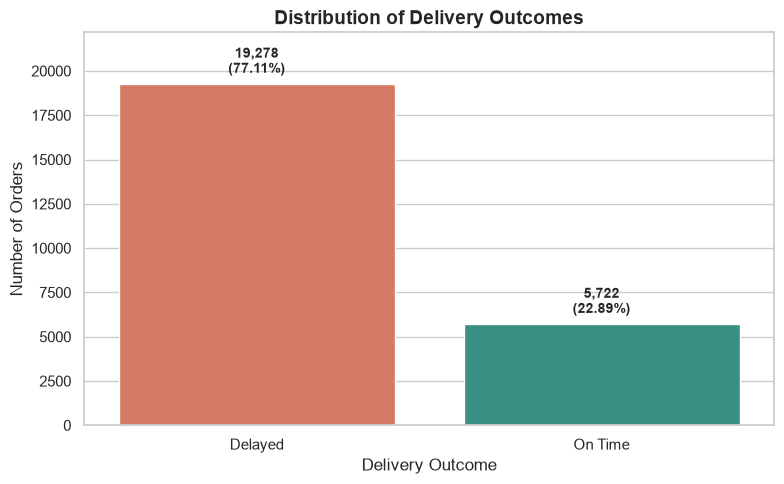

In [40]:
# Calculate delivery-outcome counts and percentages
target_distribution = (
    df_eda["Delivery_Status"]
    .value_counts()
    .reindex(["Delayed", "On Time"])
    .rename_axis("Delivery_Status")
    .reset_index(name="Record_Count")
)

target_distribution["Percentage"] = (
    target_distribution["Record_Count"]
    .div(len(df_eda))
    .mul(100)
    .round(2)
)

# Display the summary table
display(target_distribution)

# Create a colorful bar chart
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=target_distribution,
    x="Delivery_Status",
    y="Record_Count",
    hue="Delivery_Status",
    palette=delivery_palette,
    legend=False,
)

plt.title(
    "Distribution of Delivery Outcomes",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Delivery Outcome")
plt.ylabel("Number of Orders")

# Add counts and percentages above the bars
for patch, row in zip(
    ax.patches,
    target_distribution.itertuples(index=False),
):
    ax.annotate(
        f"{row.Record_Count:,}\n({row.Percentage:.2f}%)",
        (
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.ylim(
    0,
    target_distribution["Record_Count"].max() * 1.15,
)

plt.tight_layout()
# Define the output location for the chart
target_chart_path = Path(
    "../outputs/figures/target_distribution.png"
)

# Use the project-root path if needed
if not target_chart_path.parent.exists():
    target_chart_path = Path(
        "outputs/figures/target_distribution.png"
    )

# Create the folder if needed and save the chart
target_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    target_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {target_chart_path}")
plt.show()

#### Observation – Target-Variable Distribution

The table and bar chart show that the dataset contains **19,278 delayed deliveries 
(77.11%)** and **5,722 on-time deliveries (22.89%)**.

This shows that delayed deliveries make up most of the dataset, while on-time 
deliveries represent a much smaller group. The difference between the two classes 
is **13,556 records**, so the target variable is clearly imbalanced.

This imbalance may affect model performance because a model could favor the larger 
class and still appear accurate. For that reason, accuracy should not be used alone. 
Other measures such as precision, recall, F1-score, ROC-AUC, precision-recall AUC, 
and the confusion matrix will also be considered during model evaluation.

### 8.3 Descriptive Statistics of Important Numerical Variables

Descriptive statistics were calculated for selected numerical variables that may 
influence delivery performance. The analysis includes the mean, median, standard 
deviation, minimum, maximum, and skewness.

These values help show the typical range of each variable and whether any variable 
has an uneven or skewed distribution.

In [41]:
# Select important numerical variables for EDA
selected_numeric_features = [
    "Lead_Time_Days",
    "Supplier_Reliability",
    "Port_Congestion_Index",
    "Distance_to_Customer",
    "Shipping_Cost",
    "Tariff_Rate",
    "Inventory_Level",
    "Safety_Stock",
    "Carbon_Emission",
]

# Calculate descriptive statistics
numeric_eda_summary = (
    df_eda[selected_numeric_features]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .transpose()
)

# Add skewness
numeric_eda_summary["skewness"] = (
    df_eda[selected_numeric_features]
    .skew()
)

# Rename columns
numeric_eda_summary.columns = [
    "Mean",
    "Median",
    "Standard_Deviation",
    "Minimum",
    "Maximum",
    "Skewness",
]

numeric_eda_summary.round(3)

,Mean,Median,Standard_Deviation,Minimum,Maximum,Skewness
Lead_Time_Days,18.468,18.000,9.184,3.000,34.000,-0.002
Supplier_Reliability,85.007,85.105,8.685,70.001,100.000,-0.009
Port_Congestion_Index,49.870,49.789,28.917,0.001,100.000,0.005
Distance_to_Customer,5033.938,5040.485,2874.617,50.033,9999.304,-0.006
Shipping_Cost,284.356,234.362,217.440,1.501,899.811,1.005
Tariff_Rate,0.130,0.129,0.069,0.010,0.250,0.006
Inventory_Level,2555.696,2560.000,1412.651,100.000,4999.000,-0.010
Safety_Stock,525.807,527.000,274.487,50.000,999.000,-0.011
Carbon_Emission,226.785,175.245,192.073,0.633,1065.627,1.412


#### Observation – Descriptive Statistics of Numerical Variables

Most of the selected numerical variables have mean and median values that are very 
close to each other. Their skewness values are also close to zero. This is seen in 
variables such as `Lead_Time_Days`, `Supplier_Reliability`, 
`Port_Congestion_Index`, `Distance_to_Customer`, `Tariff_Rate`, 
`Inventory_Level`, and `Safety_Stock`. These variables appear to have fairly 
balanced distributions.

`Shipping_Cost` shows a different pattern. Its mean is **284.356**, while the 
median is **234.362**, with a skewness value of **1.005**. This suggests that the 
distribution is right-skewed, with some higher shipping-cost values increasing 
the average.

`Carbon_Emission` is even more right-skewed. Its mean is **226.785**, while the 
median is **175.245**, and its skewness is **1.412**. This shows that some orders 
have much higher carbon-emission values than most of the dataset.

The variables are also measured on different scales. For example, 
`Tariff_Rate` ranges from **0.010 to 0.250**, while `Distance_to_Customer` ranges 
from about **50 to 9,999**. This difference may need to be considered later when 
preparing the data for models that are affected by feature scale.

### 8.4 Univariate Analysis of Numerical Variables

Histograms were used to examine the distributions of selected numerical variables.

`Lead_Time_Days` and `Supplier_Reliability` were selected because their mean, 
median, and skewness values suggested fairly balanced distributions. 
`Shipping_Cost` and `Carbon_Emission` were selected because the descriptive 
statistics showed positive skewness.

The mean and median are marked on each chart to make the distribution patterns 
easier to compare.

Chart saved to: ..\outputs\figures\lead_time_days_distribution.png


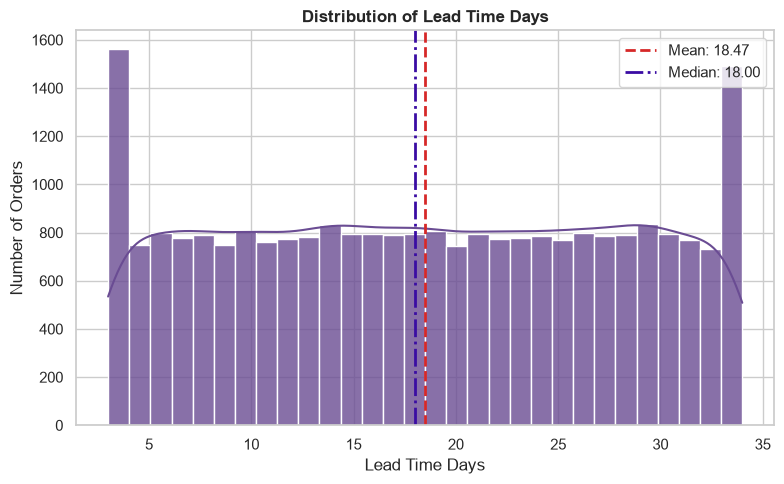

Chart saved to: ..\outputs\figures\supplier_reliability_distribution.png


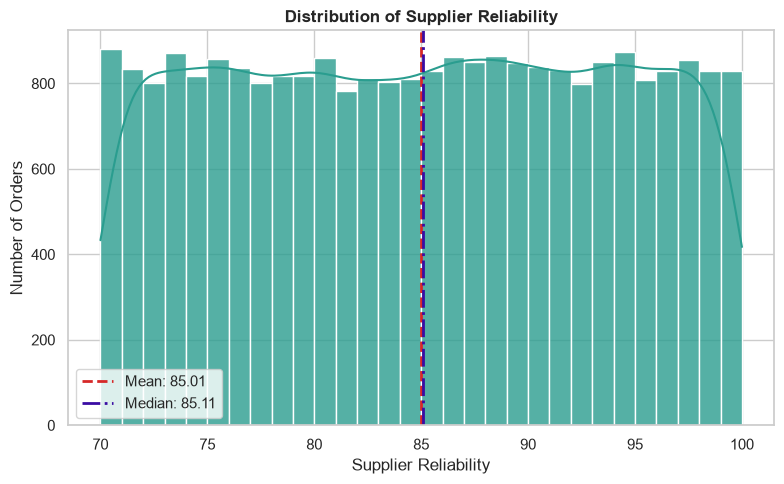

Chart saved to: ..\outputs\figures\shipping_cost_distribution.png


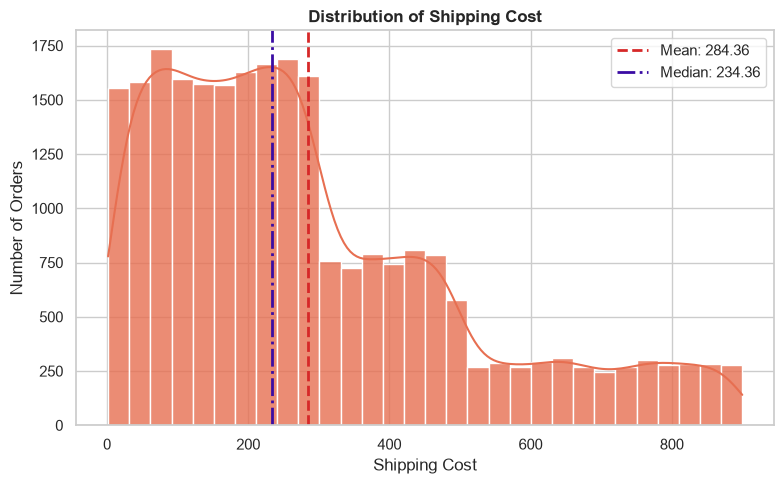

Chart saved to: ..\outputs\figures\carbon_emission_distribution.png


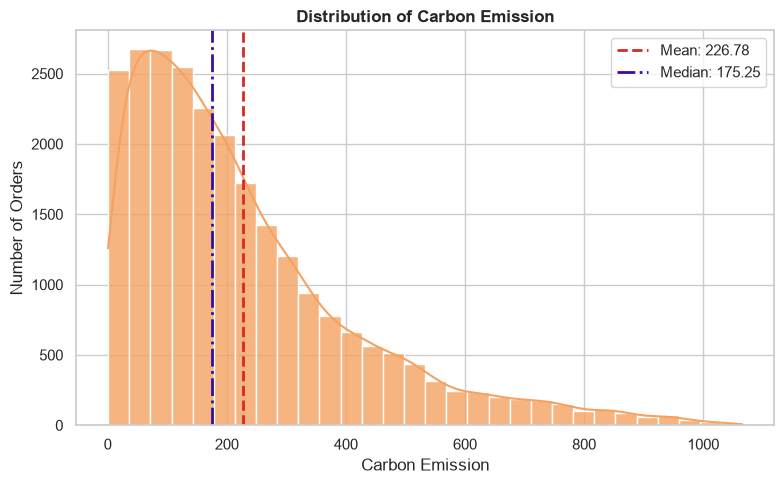

In [55]:
# Select numerical variables for distribution analysis
distribution_features = [
    "Lead_Time_Days",
    "Supplier_Reliability",
    "Shipping_Cost",
    "Carbon_Emission",
]

# Assign a different color to each variable
distribution_colors = {
    "Lead_Time_Days": "#6A4C93",
    "Supplier_Reliability": "#2A9D8F",
    "Shipping_Cost": "#E76F51",
    "Carbon_Emission": "#F4A261",
}

# Create and save a histogram for each selected variable
for feature in distribution_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df_eda,
        x=feature,
        bins=30,
        kde=True,
        color=distribution_colors[feature],
        edgecolor="white",
        alpha=0.80,
    )

    feature_mean = df_eda[feature].mean()
    feature_median = df_eda[feature].median()

    plt.axvline(
        feature_mean,
        color="#D62828",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {feature_mean:,.2f}",
    )

    plt.axvline(
        feature_median,
        color="#3A0CA3",
        linestyle="-.",
        linewidth=2,
        label=f"Median: {feature_median:,.2f}",
    )

    readable_name = feature.replace("_", " ")

    plt.title(f"Distribution of {readable_name}")
    plt.xlabel(readable_name)
    plt.ylabel("Number of Orders")
    plt.legend()
    plt.tight_layout()

    # Create a separate filename for each chart
    chart_filename = f"{feature.lower()}_distribution.png"

    numeric_chart_path = (
        Path("../outputs/figures")
        / chart_filename
    )

    if not numeric_chart_path.parent.exists():
        numeric_chart_path = (
            Path("outputs/figures")
            / chart_filename
        )

    numeric_chart_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.savefig(
        numeric_chart_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"Chart saved to: {numeric_chart_path}")

    plt.show()

#### Observation – Numerical Variable Distributions

`Lead_Time_Days` is spread fairly evenly across its range. The mean is **18.47 
days** and the median is **18 days**, which are very close. This supports the 
earlier finding that the variable has very little skewness. The higher bars near 
the minimum and maximum values may be related to how the integer values are 
distributed in the dataset.

`Supplier_Reliability` also appears fairly evenly distributed between about 
**70 and 100**. Its mean of **85.01** and median of **85.11** are almost the same, 
showing that the distribution is balanced around the center.

`Shipping_Cost` shows a right-skewed pattern. Most orders are concentrated at the 
lower and middle cost ranges, while fewer orders have very high shipping costs. 
The mean of **284.36** is higher than the median of **234.36**, which is consistent 
with the longer right side of the distribution.

`Carbon_Emission` has the clearest right-skewed distribution among the four 
variables. Most observations are concentrated at lower emission values, while a 
smaller number extend beyond **1,000**. Its mean of **226.78** is noticeably higher 
than its median of **175.25**, showing that the higher emission values pull the 
average upward.

These charts confirm that `Shipping_Cost` and `Carbon_Emission` may need closer 
attention during preprocessing and modeling. However, the higher values will not 
be removed automatically because they may represent valid supply-chain conditions.

### 8.5 Univariate Analysis of Categorical Variables

Categorical analysis was used to understand how orders are distributed across 
different business and supply-chain groups.

The analysis begins with `Product_Category`. A summary table and horizontal bar 
chart are used to compare the number and percentage of orders in each category.

,Product_Category,Record_Count,Percentage
0,Beauty,5057,20.228
1,Fashion,5017,20.068
2,Sports,5002,20.008
3,Electronics,4997,19.988
4,Home,4927,19.708


Chart saved to: ..\outputs\figures\product_category_distribution.png


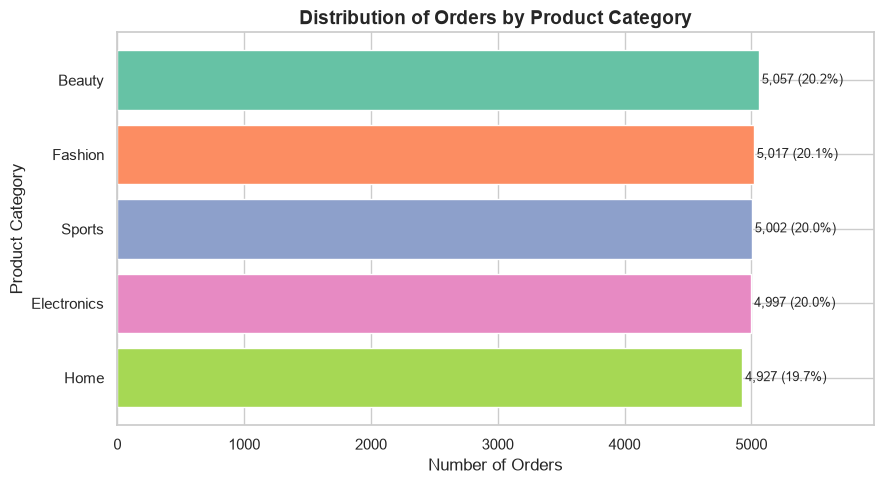

In [56]:
# Calculate product-category counts and percentages
product_category_distribution = (
    df_eda["Product_Category"]
    .value_counts()
    .rename_axis("Product_Category")
    .reset_index(name="Record_Count")
)

product_category_distribution["Percentage"] = (
    product_category_distribution["Record_Count"]
    .div(len(df_eda))
    .mul(100)
)

# Display the summary table
display(product_category_distribution.round(3))

# Create a colorful horizontal bar chart
colors = sns.color_palette(
    "Set2",
    n_colors=len(product_category_distribution),
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    product_category_distribution["Product_Category"],
    product_category_distribution["Record_Count"],
    color=colors,
    edgecolor="white",
)

plt.gca().invert_yaxis()

plt.title(
    "Distribution of Orders by Product Category",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Number of Orders")
plt.ylabel("Product Category")

# Add count and percentage labels
for bar, row in zip(
    bars,
    product_category_distribution.itertuples(index=False),
):
    plt.text(
        bar.get_width() + 25,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Record_Count:,} ({row.Percentage:.1f}%)",
        va="center",
        fontsize=9,
    )

plt.xlim(
    0,
    product_category_distribution["Record_Count"].max() * 1.18,
)

plt.tight_layout()
# Save the product-category chart
product_category_chart_path = Path(
    "../outputs/figures/product_category_distribution.png"
)

if not product_category_chart_path.parent.exists():
    product_category_chart_path = Path(
        "outputs/figures/product_category_distribution.png"
    )

product_category_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    product_category_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {product_category_chart_path}")
plt.show()

#### Observation – Product Category Distribution

The chart shows that the orders are distributed almost evenly across all five 
product categories.

`Beauty` has the highest number of orders with **5,057 records (20.2%)**, followed 
by `Fashion` with **5,017 records (20.1%)**. `Sports` and `Electronics` each 
represent about **20%** of the dataset, with **5,002** and **4,997** orders 
respectively. `Home` has the lowest number of orders with **4,927 records 
(19.7%)**.

The difference between the highest and lowest categories is small, so no product 
category is heavily overrepresented or underrepresented. This gives a fairly 
balanced base for comparing delivery performance across product categories later.

#### 8.5.2 Shipping Mode Distribution

The distribution of `Shipping_Mode` was examined to understand how orders are 
divided across the available transportation methods.

A summary table and horizontal bar chart are used to compare the number and 
percentage of orders for each shipping mode.

,Shipping_Mode,Record_Count,Percentage
0,Sea,8393,33.572
1,Air,8328,33.312
2,Ground,8279,33.116


Chart saved to: ..\outputs\figures\shipping_mode_distribution.png


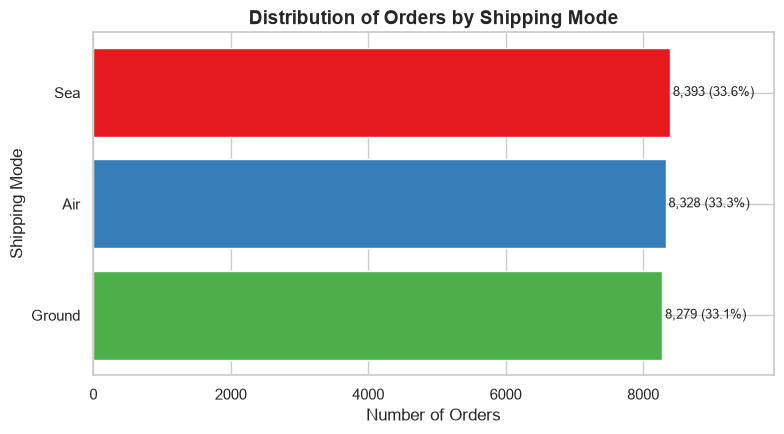

In [57]:
# Calculate shipping-mode counts and percentages
shipping_mode_distribution = (
    df_eda["Shipping_Mode"]
    .value_counts()
    .rename_axis("Shipping_Mode")
    .reset_index(name="Record_Count")
)

shipping_mode_distribution["Percentage"] = (
    shipping_mode_distribution["Record_Count"]
    .div(len(df_eda))
    .mul(100)
)

# Display the summary table
display(shipping_mode_distribution.round(3))

# Create a colorful horizontal bar chart
colors = sns.color_palette(
    "Set1",
    n_colors=len(shipping_mode_distribution),
)

plt.figure(figsize=(8, 4.5))

bars = plt.barh(
    shipping_mode_distribution["Shipping_Mode"],
    shipping_mode_distribution["Record_Count"],
    color=colors,
    edgecolor="white",
)

plt.gca().invert_yaxis()

plt.title(
    "Distribution of Orders by Shipping Mode",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Number of Orders")
plt.ylabel("Shipping Mode")

# Add count and percentage labels
for bar, row in zip(
    bars,
    shipping_mode_distribution.itertuples(index=False),
):
    plt.text(
        bar.get_width() + 40,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Record_Count:,} ({row.Percentage:.1f}%)",
        va="center",
        fontsize=9,
    )

plt.xlim(
    0,
    shipping_mode_distribution["Record_Count"].max() * 1.18,
)

plt.tight_layout()
# Save the shipping-mode chart
shipping_mode_chart_path = Path(
    "../outputs/figures/shipping_mode_distribution.png"
)

if not shipping_mode_chart_path.parent.exists():
    shipping_mode_chart_path = Path(
        "outputs/figures/shipping_mode_distribution.png"
    )

shipping_mode_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    shipping_mode_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {shipping_mode_chart_path}")
plt.show()

#### Observation – Shipping Mode Distribution

The three shipping modes are distributed almost evenly across the dataset.

`Sea` has the highest number of orders with **8,393 records (33.6%)**, followed by 
`Air` with **8,328 records (33.3%)**. `Ground` has the lowest number of orders with 
**8,279 records (33.1%)**.

The difference between the highest and lowest shipping modes is only **114 orders**, 
so no shipping mode is heavily overrepresented. This balanced distribution will 
help when comparing delivery performance across shipping modes later in the analysis.

#### 8.5.3 Region Distribution

The distribution of `Region` was examined to understand how orders are spread 
across the five geographic regions in the dataset.

A summary table and horizontal bar chart are used to compare the number and 
percentage of orders in each region.

,Region,Record_Count,Percentage
0,Latin America,5113,20.452
1,Asia Pacific,4993,19.972
2,North America,4990,19.960
3,Europe,4963,19.852
4,Middle East,4941,19.764


Chart saved to: ..\outputs\figures\region_distribution.png


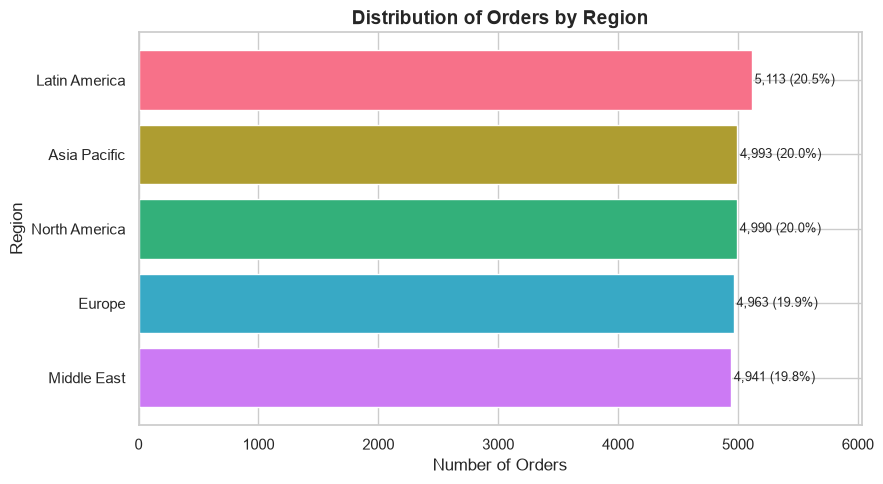

In [58]:
# Calculate region counts and percentages
region_distribution = (
    df_eda["Region"]
    .value_counts()
    .rename_axis("Region")
    .reset_index(name="Record_Count")
)

region_distribution["Percentage"] = (
    region_distribution["Record_Count"]
    .div(len(df_eda))
    .mul(100)
)

# Display the summary table
display(region_distribution.round(3))

# Create a colorful horizontal bar chart
colors = sns.color_palette(
    "husl",
    n_colors=len(region_distribution),
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    region_distribution["Region"],
    region_distribution["Record_Count"],
    color=colors,
    edgecolor="white",
)

plt.gca().invert_yaxis()

plt.title(
    "Distribution of Orders by Region",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Number of Orders")
plt.ylabel("Region")

# Add count and percentage labels
for bar, row in zip(
    bars,
    region_distribution.itertuples(index=False),
):
    plt.text(
        bar.get_width() + 25,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Record_Count:,} ({row.Percentage:.1f}%)",
        va="center",
        fontsize=9,
    )

plt.xlim(
    0,
    region_distribution["Record_Count"].max() * 1.18,
)

plt.tight_layout()
# Save the region-distribution chart
region_chart_path = Path(
    "../outputs/figures/region_distribution.png"
)

if not region_chart_path.parent.exists():
    region_chart_path = Path(
        "outputs/figures/region_distribution.png"
    )

region_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    region_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {region_chart_path}")
plt.show()

#### Observation – Region Distribution

The orders are distributed almost evenly across the five regions.

`Latin America` has the highest number of orders with **5,113 records (20.452%)**. 
`Asia Pacific` has **4,993 records (19.972%)**, followed closely by 
`North America` with **4,990 records (19.960%)**.

`Europe` contains **4,963 records (19.852%)**, while `Middle East` has the lowest 
number of orders with **4,941 records (19.764%)**.

The difference between the highest and lowest regions is only **172 orders**, so 
there is no major imbalance in the regional distribution. This makes it easier 
to compare delivery performance across regions in the next stage of the analysis.

#### 8.5.4 Country Distribution

The distribution of `Country` was examined to understand how orders are spread 
across the 15 destination countries in the dataset.

A summary table and horizontal bar chart are used to compare the number and 
percentage of orders for each country.

,Country,Record_Count,Percentage
0,Brazil,2578,10.312
1,Chile,2535,10.140
2,Saudi Arabia,2525,10.100
3,UAE,2416,9.664
4,Canada,1700,6.800
5,USA,1646,6.584
6,Mexico,1644,6.576
7,Singapore,1301,5.204
8,India,1250,5.000
9,UK,1245,4.980


Chart saved to: ..\outputs\figures\country_distribution.png


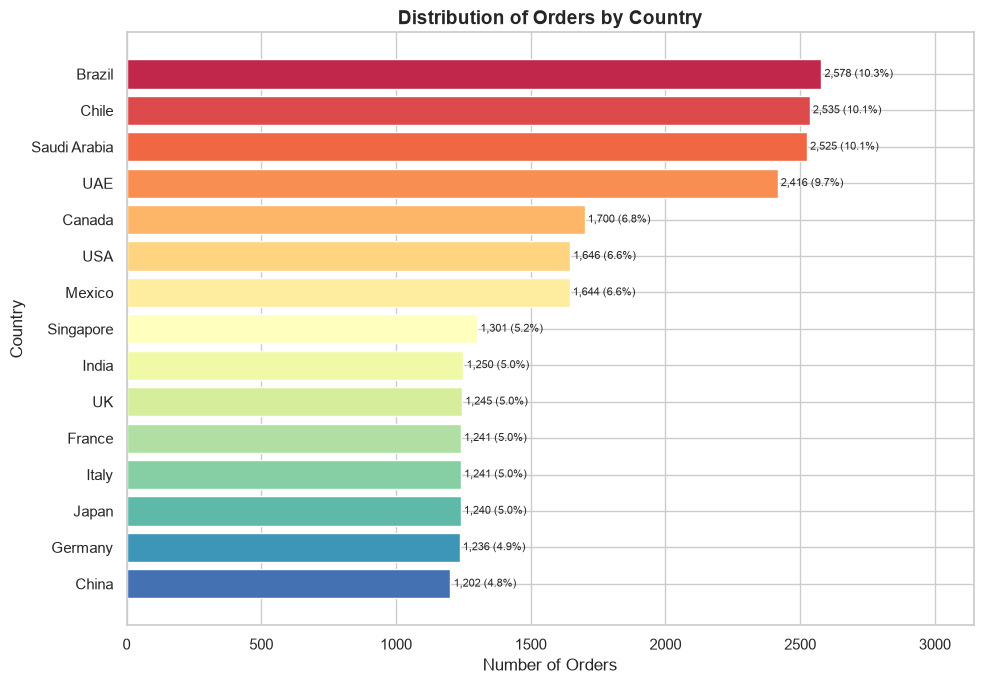

In [59]:
# Calculate country counts and percentages
country_distribution = (
    df_eda["Country"]
    .value_counts()
    .rename_axis("Country")
    .reset_index(name="Record_Count")
)

country_distribution["Percentage"] = (
    country_distribution["Record_Count"]
    .div(len(df_eda))
    .mul(100)
)

# Display the summary table
display(country_distribution.round(3))

# Create a colorful horizontal bar chart
colors = sns.color_palette(
    "Spectral",
    n_colors=len(country_distribution),
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    country_distribution["Country"],
    country_distribution["Record_Count"],
    color=colors,
    edgecolor="white",
)

plt.gca().invert_yaxis()

plt.title(
    "Distribution of Orders by Country",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Number of Orders")
plt.ylabel("Country")

# Add count and percentage labels
for bar, row in zip(
    bars,
    country_distribution.itertuples(index=False),
):
    plt.text(
        bar.get_width() + 12,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Record_Count:,} ({row.Percentage:.1f}%)",
        va="center",
        fontsize=8,
    )

plt.xlim(
    0,
    country_distribution["Record_Count"].max() * 1.22,
)

plt.tight_layout()
# Save the country-distribution chart
country_chart_path = Path(
    "../outputs/figures/country_distribution.png"
)

if not country_chart_path.parent.exists():
    country_chart_path = Path(
        "outputs/figures/country_distribution.png"
    )

country_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    country_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {country_chart_path}")
plt.show()

#### Observation – Country Distribution

The number of orders is not evenly distributed across all 15 countries.

`Brazil` has the highest number of orders with **2,578 records (10.312%)**, 
followed by `Chile` with **2,535 records (10.140%)** and `Saudi Arabia` with 
**2,525 records (10.100%)**. `UAE` also has a relatively high number of orders, 
with **2,416 records (9.664%)**.

Countries such as `Canada`, `USA`, and `Mexico` each represent around **6.6% to 
6.8%** of the dataset. The remaining countries mostly account for around **5%** 
each. `China` has the lowest number of orders with **1,202 records (4.808%)**.

The country distribution is less balanced than the product-category, shipping-mode, 
and regional distributions. Therefore, raw delayed-order counts should not be used 
alone when comparing countries. Delivery percentages will provide a fairer comparison 
because some countries contain more orders than others.

#### 8.5.5 Customer Segment Distribution

The distribution of `Customer_Segment` was examined to understand how orders are 
divided between the customer groups in the dataset.

A summary table and bar chart are used to compare the number and percentage of 
orders in each customer segment.

,Customer_Segment,Record_Count,Percentage
0,Wholesale,12527,50.108
1,Retail,12473,49.892


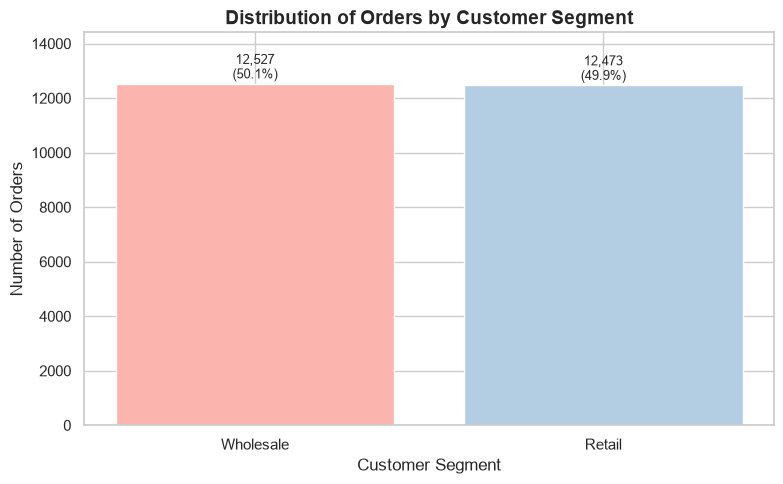

In [60]:
# Calculate customer-segment counts and percentages
customer_segment_distribution = (
    df_eda["Customer_Segment"]
    .value_counts()
    .rename_axis("Customer_Segment")
    .reset_index(name="Record_Count")
)

customer_segment_distribution["Percentage"] = (
    customer_segment_distribution["Record_Count"]
    .div(len(df_eda))
    .mul(100)
)

# Display the summary table
display(customer_segment_distribution.round(3))

# Create a colorful bar chart
colors = sns.color_palette(
    "Pastel1",
    n_colors=len(customer_segment_distribution),
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_segment_distribution["Customer_Segment"],
    customer_segment_distribution["Record_Count"],
    color=colors,
    edgecolor="white",
)

plt.title(
    "Distribution of Orders by Customer Segment",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

# Add count and percentage labels
for bar, row in zip(
    bars,
    customer_segment_distribution.itertuples(index=False),
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{row.Record_Count:,}\n({row.Percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.ylim(
    0,
    customer_segment_distribution["Record_Count"].max() * 1.15,
)

plt.tight_layout()
plt.show()

#### Observation – Customer Segment Distribution

The orders are almost equally divided between the two customer segments.

`Wholesale` has **12,527 orders (50.108%)**, while `Retail` has **12,473 orders 
(49.892%)**. The difference between the two segments is only **54 orders**.

This shows that the customer-segment distribution is well balanced. Therefore, 
future comparisons between wholesale and retail delivery performance are unlikely 
to be affected by a large difference in the number of records.

### 8.6 Bivariate Analysis of Shipping Mode and Delivery Outcome

A bivariate analysis was performed to compare delivery outcomes across the three 
shipping modes.

The number and percentage of delayed and on-time deliveries were calculated for 
Air, Ground, and Sea shipments. A 100% stacked bar chart is used so that the 
delivery-outcome proportions can be compared fairly, even if the shipping modes 
contain slightly different numbers of orders.

Delivery_Status,Delayed,On Time,Total_Orders,Delayed_Percentage,On_Time_Percentage
Shipping_Mode,,,,,
Air,6361,1967,8328,76.38,23.62
Ground,6433,1846,8279,77.70,22.30
Sea,6484,1909,8393,77.25,22.75


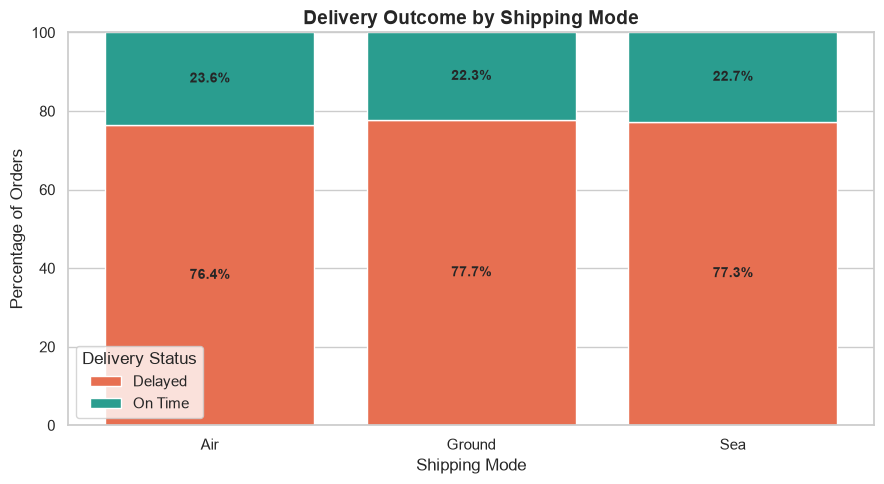

In [61]:
# Calculate delivery counts by shipping mode
shipping_delivery_counts = pd.crosstab(
    df_eda["Shipping_Mode"],
    df_eda["Delivery_Status"],
)

# Keep the delivery classes in a consistent order
shipping_delivery_counts = (
    shipping_delivery_counts
    .reindex(columns=["Delayed", "On Time"])
)

# Calculate delivery percentages within each shipping mode
shipping_delivery_percentages = (
    shipping_delivery_counts
    .div(
        shipping_delivery_counts.sum(axis=1),
        axis=0,
    )
    .mul(100)
)

# Create a summary table
shipping_delivery_summary = (
    shipping_delivery_counts.copy()
)

shipping_delivery_summary["Total_Orders"] = (
    shipping_delivery_counts.sum(axis=1)
)

shipping_delivery_summary["Delayed_Percentage"] = (
    shipping_delivery_percentages["Delayed"]
)

shipping_delivery_summary["On_Time_Percentage"] = (
    shipping_delivery_percentages["On Time"]
)

# Display exact results
display(shipping_delivery_summary.round(2))

# Create a 100% stacked bar chart
plt.figure(figsize=(9, 5))

bottom_values = np.zeros(
    len(shipping_delivery_percentages)
)

for status in ["Delayed", "On Time"]:
    values = shipping_delivery_percentages[status]

    bars = plt.bar(
        shipping_delivery_percentages.index,
        values,
        bottom=bottom_values,
        label=status,
        color=delivery_palette[status],
        edgecolor="white",
    )

    # Add percentage labels inside each section
    for bar, value, bottom in zip(
        bars,
        values,
        bottom_values,
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bottom + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

    bottom_values += values.to_numpy()

plt.title(
    "Delivery Outcome by Shipping Mode",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Shipping Mode")
plt.ylabel("Percentage of Orders")
plt.ylim(0, 100)
plt.legend(title="Delivery Status")
plt.tight_layout()
plt.show()

#### Observation – Delivery Outcome by Shipping Mode

The chart and summary table show that delivery performance is very similar across 
all three shipping modes.

`Air` has the highest on-time delivery rate at **23.62%**, with **1,967 on-time 
orders** out of **8,328 total orders**. `Sea` follows with an on-time rate of 
**22.75%**, while `Ground` has the lowest on-time rate at **22.30%**.

The difference between the highest and lowest on-time delivery rates is only 
**1.32 percentage points**. This means shipping mode shows only a small difference 
in delivery performance when viewed by itself.

All three shipping modes still have delayed-delivery rates above **76%**, which 
matches the overall imbalance seen in the target variable. Shipping mode may still 
be useful when combined with other variables, but it does not appear to strongly 
separate delayed and on-time deliveries on its own.

### 8.7 Bivariate Analysis of Region and Delivery Outcome

Delivery outcomes were compared across the five geographic regions in the dataset.

The number and percentage of delayed and on-time orders were calculated for each 
region. A 100% stacked bar chart was used so that the regional percentages could 
be compared fairly, even though the regions contain slightly different numbers 
of orders.

Delivery_Status,Delayed,On Time,Total_Orders,Delayed_Percentage,On_Time_Percentage
Region,,,,,
Latin America,3915,1198,5113,76.57,23.43
Middle East,3801,1140,4941,76.93,23.07
North America,3847,1143,4990,77.09,22.91
Europe,3835,1128,4963,77.27,22.73
Asia Pacific,3880,1113,4993,77.71,22.29


Chart saved to: ..\outputs\figures\delivery_outcome_by_region.png


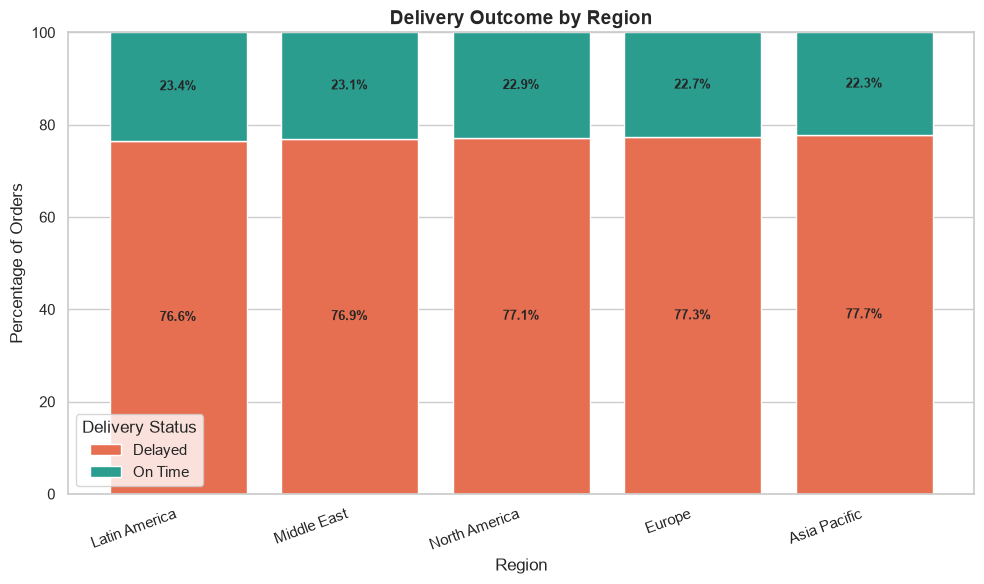

In [62]:
# Calculate delivery counts by region
region_delivery_counts = pd.crosstab(
    df_eda["Region"],
    df_eda["Delivery_Status"],
)

# Keep delivery classes in a consistent order
region_delivery_counts = (
    region_delivery_counts
    .reindex(columns=["Delayed", "On Time"])
)

# Calculate percentages within each region
region_delivery_percentages = (
    region_delivery_counts
    .div(
        region_delivery_counts.sum(axis=1),
        axis=0,
    )
    .mul(100)
)

# Create a summary table
region_delivery_summary = (
    region_delivery_counts.copy()
)

region_delivery_summary["Total_Orders"] = (
    region_delivery_counts.sum(axis=1)
)

region_delivery_summary["Delayed_Percentage"] = (
    region_delivery_percentages["Delayed"]
)

region_delivery_summary["On_Time_Percentage"] = (
    region_delivery_percentages["On Time"]
)

# Sort regions by on-time delivery percentage
region_delivery_summary = (
    region_delivery_summary
    .sort_values(
        "On_Time_Percentage",
        ascending=False,
    )
)

region_order = region_delivery_summary.index

# Display exact results
display(region_delivery_summary.round(2))

# Create a 100% stacked bar chart
plt.figure(figsize=(10, 6))

bottom_values = np.zeros(
    len(region_delivery_percentages)
)

for status in ["Delayed", "On Time"]:
    values = (
        region_delivery_percentages
        .loc[region_order, status]
    )

    bars = plt.bar(
        region_order,
        values,
        bottom=bottom_values,
        label=status,
        color=delivery_palette[status],
        edgecolor="white",
    )

    # Add percentage labels inside each section
    for bar, value, bottom in zip(
        bars,
        values,
        bottom_values,
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bottom + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

    bottom_values += values.to_numpy()

plt.title(
    "Delivery Outcome by Region",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Region")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.legend(title="Delivery Status")
plt.tight_layout()

# Save the chart
region_outcome_chart_path = Path(
    "../outputs/figures/delivery_outcome_by_region.png"
)

if not region_outcome_chart_path.parent.exists():
    region_outcome_chart_path = Path(
        "outputs/figures/delivery_outcome_by_region.png"
    )

region_outcome_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    region_outcome_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {region_outcome_chart_path}")

plt.show()

#### Observation – Delivery Outcome by Region

The delivery percentages are very similar across all five regions.

`Latin America` has the highest on-time delivery rate at **23.43%**, followed by 
`Middle East` at **23.07%** and `North America` at **22.91%**.

`Europe` has an on-time delivery rate of **22.73%**, while `Asia Pacific` has the 
lowest rate at **22.29%**.

The difference between the highest and lowest on-time delivery rates is only 
**1.14 percentage points**. This shows that region does not create a major 
difference in delivery performance when examined by itself.

All regions have delayed-delivery rates above **76%**, which is consistent with 
the overall target-variable distribution. Region may still be useful when combined 
with other variables, but it does not appear to strongly separate delayed and 
on-time deliveries on its own.

### 8.8 Bivariate Analysis of Product Category and Delivery Outcome

Delivery outcomes were compared across the five product categories.

The delayed and on-time percentages were calculated within each product category. 
A 100% stacked bar chart was used so that delivery performance could be compared 
fairly across categories.

Delivery_Status,Delayed,On Time,Total_Orders,Delayed_Percentage,On_Time_Percentage
Product_Category,,,,,
Beauty,3854,1203,5057,76.21,23.79
Electronics,3834,1163,4997,76.73,23.27
Fashion,3878,1139,5017,77.30,22.70
Sports,3878,1124,5002,77.53,22.47
Home,3834,1093,4927,77.82,22.18


Chart saved to: ..\outputs\figures\delivery_outcome_by_product_category.png


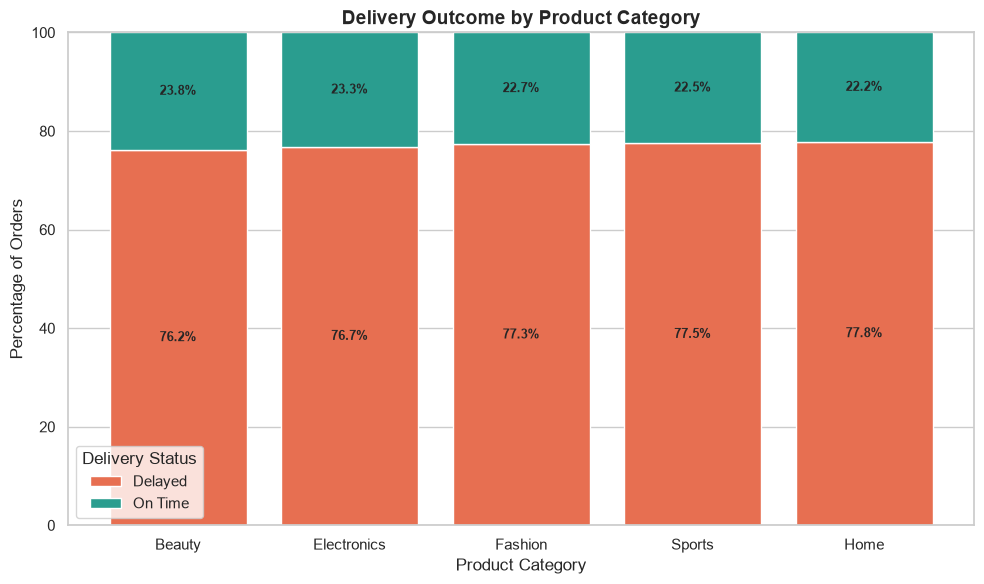

In [63]:
# Calculate delivery counts by product category
product_delivery_counts = pd.crosstab(
    df_eda["Product_Category"],
    df_eda["Delivery_Status"],
)

# Keep delivery classes in a consistent order
product_delivery_counts = (
    product_delivery_counts
    .reindex(columns=["Delayed", "On Time"])
)

# Calculate percentages within each product category
product_delivery_percentages = (
    product_delivery_counts
    .div(
        product_delivery_counts.sum(axis=1),
        axis=0,
    )
    .mul(100)
)

# Create a summary table
product_delivery_summary = product_delivery_counts.copy()

product_delivery_summary["Total_Orders"] = (
    product_delivery_counts.sum(axis=1)
)

product_delivery_summary["Delayed_Percentage"] = (
    product_delivery_percentages["Delayed"]
)

product_delivery_summary["On_Time_Percentage"] = (
    product_delivery_percentages["On Time"]
)

# Sort by on-time delivery percentage
product_delivery_summary = (
    product_delivery_summary
    .sort_values(
        "On_Time_Percentage",
        ascending=False,
    )
)

product_order = product_delivery_summary.index

# Display the exact results
display(product_delivery_summary.round(2))

# Create a 100% stacked bar chart
plt.figure(figsize=(10, 6))

bottom_values = np.zeros(len(product_order))

for status in ["Delayed", "On Time"]:
    values = product_delivery_percentages.loc[
        product_order,
        status,
    ]

    bars = plt.bar(
        product_order,
        values,
        bottom=bottom_values,
        label=status,
        color=delivery_palette[status],
        edgecolor="white",
    )

    for bar, value, bottom in zip(
        bars,
        values,
        bottom_values,
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bottom + value / 2,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

    bottom_values += values.to_numpy()

plt.title(
    "Delivery Outcome by Product Category",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Product Category")
plt.ylabel("Percentage of Orders")
plt.ylim(0, 100)
plt.legend(title="Delivery Status")
plt.tight_layout()

# Save the chart
product_outcome_chart_path = Path(
    "../outputs/figures/delivery_outcome_by_product_category.png"
)

if not product_outcome_chart_path.parent.exists():
    product_outcome_chart_path = Path(
        "outputs/figures/delivery_outcome_by_product_category.png"
    )

product_outcome_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    product_outcome_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {product_outcome_chart_path}")

plt.show()

#### Observation – Delivery Outcome by Product Category

The delivery percentages are quite similar across all five product categories.

`Beauty` has the highest on-time delivery rate at **23.79%**, followed by 
`Electronics` at **23.27%**. `Fashion` has an on-time delivery rate of **22.70%**, 
while `Sports` has **22.47%**.

`Home` has the lowest on-time delivery rate at **22.18%**.

The difference between the highest and lowest on-time delivery rates is only 
**1.61 percentage points**. This shows that product category does not create a 
large difference in delivery performance when examined by itself.

All product categories have delayed-delivery rates above **76%**, which is similar 
to the overall target distribution. Product category may still be useful when 
combined with other variables, but it does not strongly separate delayed and 
on-time deliveries on its own.

### 8.9 Bivariate Analysis of Country and Delivery Outcome

Delivery performance was compared across the 15 destination countries.

Since the countries contain different numbers of orders, the on-time delivery 
percentage was calculated for each country. This provides a fairer comparison than 
using only the number of delayed or on-time orders.

Delivery_Status,Delayed,On Time,Total_Orders,Delayed_Percentage,On_Time_Percentage
Country,,,,,
Chile,1924,611,2535,75.90,24.10
USA,1251,395,1646,76.00,24.00
China,915,287,1202,76.12,23.88
Germany,949,287,1236,76.78,23.22
UAE,1857,559,2416,76.86,23.14
France,954,287,1241,76.87,23.13
Saudi Arabia,1944,581,2525,76.99,23.01
Mexico,1269,375,1644,77.19,22.81
Brazil,1991,587,2578,77.23,22.77


Chart saved to: ..\outputs\figures\on_time_delivery_rate_by_country.png


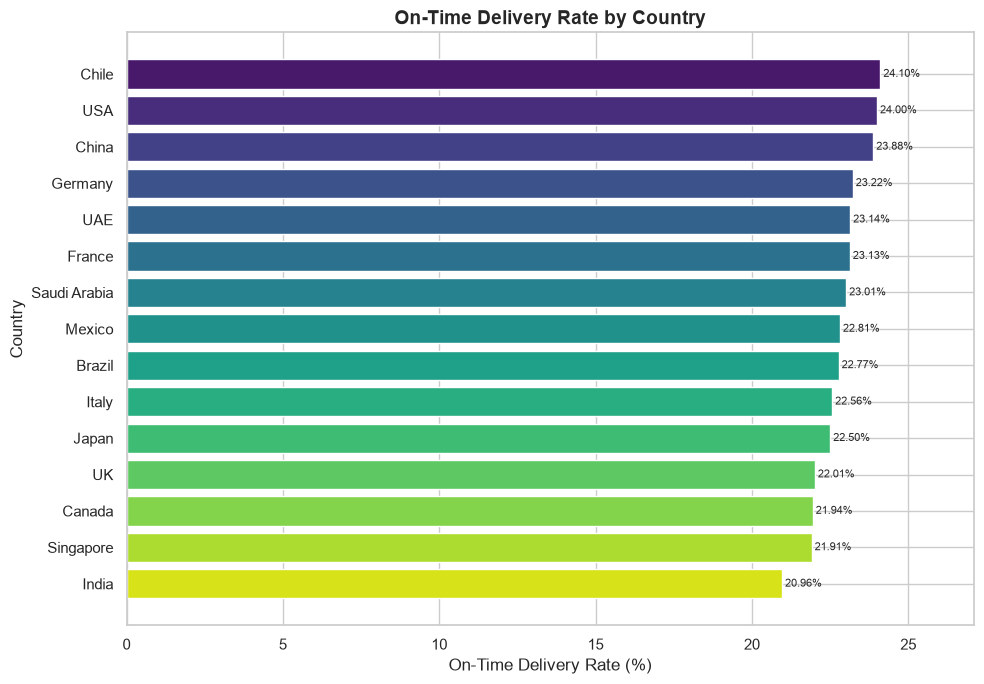

In [64]:
# Calculate delivery counts by country
country_delivery_counts = pd.crosstab(
    df_eda["Country"],
    df_eda["Delivery_Status"],
)

# Keep delivery classes in a consistent order
country_delivery_counts = (
    country_delivery_counts
    .reindex(columns=["Delayed", "On Time"])
)

# Calculate percentages within each country
country_delivery_percentages = (
    country_delivery_counts
    .div(
        country_delivery_counts.sum(axis=1),
        axis=0,
    )
    .mul(100)
)

# Create the country-level summary table
country_delivery_summary = country_delivery_counts.copy()

country_delivery_summary["Total_Orders"] = (
    country_delivery_counts.sum(axis=1)
)

country_delivery_summary["Delayed_Percentage"] = (
    country_delivery_percentages["Delayed"]
)

country_delivery_summary["On_Time_Percentage"] = (
    country_delivery_percentages["On Time"]
)

# Sort countries from highest to lowest on-time rate
country_delivery_summary = (
    country_delivery_summary
    .sort_values(
        "On_Time_Percentage",
        ascending=False,
    )
)

# Display the exact results
display(country_delivery_summary.round(2))

# Create a horizontal bar chart
colors = sns.color_palette(
    "viridis",
    n_colors=len(country_delivery_summary),
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    country_delivery_summary.index,
    country_delivery_summary["On_Time_Percentage"],
    color=colors,
    edgecolor="white",
)

plt.gca().invert_yaxis()

plt.title(
    "On-Time Delivery Rate by Country",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("On-Time Delivery Rate (%)")
plt.ylabel("Country")

# Add percentage labels
for bar, rate in zip(
    bars,
    country_delivery_summary["On_Time_Percentage"],
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.2f}%",
        va="center",
        fontsize=8,
    )

plt.xlim(
    0,
    country_delivery_summary["On_Time_Percentage"].max() + 3,
)

plt.tight_layout()

# Save the chart
country_outcome_chart_path = Path(
    "../outputs/figures/on_time_delivery_rate_by_country.png"
)

if not country_outcome_chart_path.parent.exists():
    country_outcome_chart_path = Path(
        "outputs/figures/on_time_delivery_rate_by_country.png"
    )

country_outcome_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    country_outcome_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {country_outcome_chart_path}")

plt.show()

#### Observation – Delivery Outcome by Country

The on-time delivery rate varies more by country than it did by shipping mode, 
region, or product category.

`Chile` has the highest on-time delivery rate at **24.10%**, followed by the 
`USA` at **24.00%** and `China` at **23.88%**.

At the lower end, `Singapore` has an on-time delivery rate of **21.91%**, while 
`India` has the lowest rate at **20.96%**.

The difference between the highest and lowest on-time delivery rates is **3.14 
percentage points**. This is still not a very large gap, but it is more noticeable 
than the differences found in the earlier categorical comparisons.

All countries continue to have delayed-delivery rates above **75%**. This shows 
that delays are common across the dataset rather than being limited to only one or 
two countries.

Country may still be useful as a predictor, especially when combined with other 
factors such as distance, tariff rate, port congestion, shipping mode, and weather 
conditions.

### 8.10 Bivariate Analysis of Lead Time and Delivery Outcome

Lead time was compared between delayed and on-time deliveries to check whether the 
number of lead-time days differs between the two delivery groups.

The mean, median, minimum, and maximum lead-time values were calculated for each 
delivery status. A boxplot was also used to compare the spread of lead time across 
the two groups.

,Record_Count,Mean,Median,Standard_Deviation,Minimum,Maximum
Delivery_Status,,,,,,
Delayed,19278,21.42,22.0,8.24,3,34
On Time,5722,8.54,8.0,3.46,3,14


Chart saved to: ..\outputs\figures\lead_time_by_delivery_outcome.png


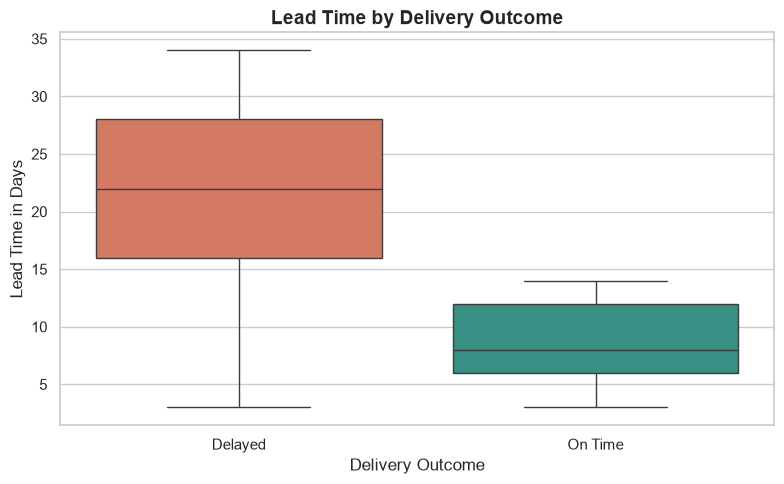

In [65]:
# Calculate lead-time statistics by delivery status
lead_time_delivery_summary = (
    df_eda.groupby("Delivery_Status")["Lead_Time_Days"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .reindex(["Delayed", "On Time"])
)

# Rename columns for readability
lead_time_delivery_summary.columns = [
    "Record_Count",
    "Mean",
    "Median",
    "Standard_Deviation",
    "Minimum",
    "Maximum",
]

# Display the summary table
display(lead_time_delivery_summary.round(2))

# Create a boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Delivery_Status",
    y="Lead_Time_Days",
    hue="Delivery_Status",
    order=["Delayed", "On Time"],
    palette=delivery_palette,
    legend=False,
)

plt.title(
    "Lead Time by Delivery Outcome",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Delivery Outcome")
plt.ylabel("Lead Time in Days")
plt.tight_layout()

# Save the chart
lead_time_outcome_chart_path = Path(
    "../outputs/figures/lead_time_by_delivery_outcome.png"
)

if not lead_time_outcome_chart_path.parent.exists():
    lead_time_outcome_chart_path = Path(
        "outputs/figures/lead_time_by_delivery_outcome.png"
    )

lead_time_outcome_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    lead_time_outcome_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {lead_time_outcome_chart_path}")

plt.show()

#### Observation – Lead Time by Delivery Outcome

Lead time shows a clear difference between delayed and on-time deliveries.

Delayed orders have a mean lead time of **21.42 days** and a median of **22 days**. 
In comparison, on-time orders have a much lower mean lead time of **8.54 days** 
and a median of **8 days**.

The maximum lead time for on-time orders is **14 days**, while delayed orders 
extend up to **34 days**. The boxplot also shows that the delayed group generally 
has higher lead-time values and a wider spread than the on-time group.

This suggests that `Lead_Time_Days` may be an important variable for predicting 
delivery outcome. However, its exact definition should be checked before modeling. 
If it represents a value known before shipment, it can be used as a predictor. If 
it represents the actual time measured after delivery, it may create data leakage 
because it would already contain information about the final delivery result.

### 8.11 Bivariate Analysis of Supplier Reliability and Delivery Outcome

Supplier reliability was compared between delayed and on-time deliveries to check 
whether the reliability score differs across the two delivery groups.

The mean, median, minimum, and maximum supplier-reliability values were calculated 
for each delivery status. A boxplot was also used to compare the spread of the 
scores.

,Record_Count,Mean,Median,Standard_Deviation,Minimum,Maximum
Delivery_Status,,,,,,
Delayed,19278,85.01,85.11,8.69,70.0,100.00
On Time,5722,84.99,85.10,8.68,70.0,99.99


Chart saved to: ..\outputs\figures\supplier_reliability_by_delivery_outcome.png


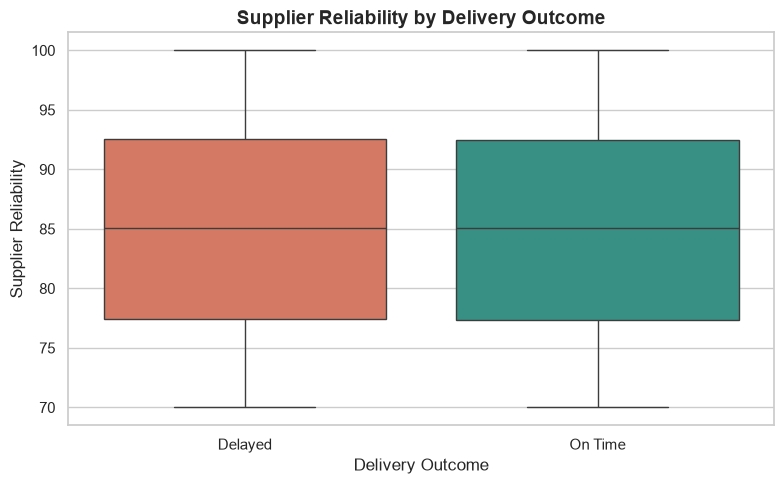

In [66]:
# Calculate supplier-reliability statistics by delivery status
supplier_reliability_summary = (
    df_eda.groupby("Delivery_Status")["Supplier_Reliability"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .reindex(["Delayed", "On Time"])
)

# Rename columns for readability
supplier_reliability_summary.columns = [
    "Record_Count",
    "Mean",
    "Median",
    "Standard_Deviation",
    "Minimum",
    "Maximum",
]

# Display the summary table
display(supplier_reliability_summary.round(2))

# Create a boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Delivery_Status",
    y="Supplier_Reliability",
    hue="Delivery_Status",
    order=["Delayed", "On Time"],
    palette=delivery_palette,
    legend=False,
)

plt.title(
    "Supplier Reliability by Delivery Outcome",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Delivery Outcome")
plt.ylabel("Supplier Reliability")
plt.tight_layout()

# Save the chart
supplier_outcome_chart_path = Path(
    "../outputs/figures/supplier_reliability_by_delivery_outcome.png"
)

if not supplier_outcome_chart_path.parent.exists():
    supplier_outcome_chart_path = Path(
        "outputs/figures/supplier_reliability_by_delivery_outcome.png"
    )

supplier_outcome_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    supplier_outcome_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {supplier_outcome_chart_path}")

plt.show()

#### Observation – Supplier Reliability by Delivery Outcome

Supplier reliability is almost the same for delayed and on-time deliveries.

Delayed orders have a mean supplier-reliability score of **85.01** and a median of 
**85.11**. On-time orders have a mean of **84.99** and a median of **85.10**.

The minimum, maximum, standard deviation, and overall spread are also nearly 
identical for both groups. The boxplot shows a large amount of overlap between 
delayed and on-time deliveries.

This suggests that `Supplier_Reliability` does not show a clear relationship with 
delivery outcome when examined by itself. It may still contribute when combined 
with other variables, but it is unlikely to be a strong standalone predictor.

### 8.12 Bivariate Analysis of Port Congestion and Delivery Outcome

Port congestion was compared between delayed and on-time deliveries to check 
whether congestion levels differ across the two delivery groups.

The mean, median, minimum, and maximum congestion values were calculated for each 
delivery status. A boxplot was also used to compare the spread of the values.

,Record_Count,Mean,Median,Standard_Deviation,Minimum,Maximum
Delivery_Status,,,,,,
Delayed,19278,55.89,61.27,28.92,0.00,100.0
On Time,5722,29.58,29.70,17.39,0.01,60.0


Chart saved to: ..\outputs\figures\port_congestion_by_delivery_outcome.png


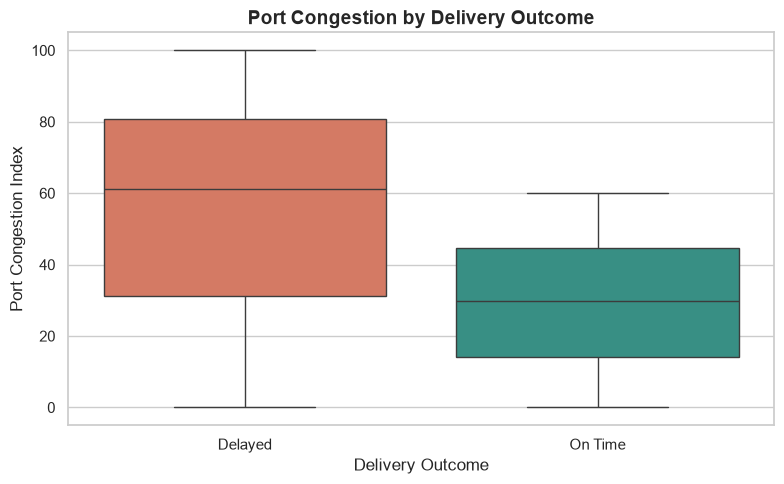

In [67]:
# Calculate port-congestion statistics by delivery status
port_congestion_summary = (
    df_eda.groupby("Delivery_Status")["Port_Congestion_Index"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .reindex(["Delayed", "On Time"])
)

# Rename columns for readability
port_congestion_summary.columns = [
    "Record_Count",
    "Mean",
    "Median",
    "Standard_Deviation",
    "Minimum",
    "Maximum",
]

# Display the summary table
display(port_congestion_summary.round(2))

# Create a boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Delivery_Status",
    y="Port_Congestion_Index",
    hue="Delivery_Status",
    order=["Delayed", "On Time"],
    palette=delivery_palette,
    legend=False,
)

plt.title(
    "Port Congestion by Delivery Outcome",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Delivery Outcome")
plt.ylabel("Port Congestion Index")
plt.tight_layout()

# Save the chart
port_congestion_chart_path = Path(
    "../outputs/figures/port_congestion_by_delivery_outcome.png"
)

if not port_congestion_chart_path.parent.exists():
    port_congestion_chart_path = Path(
        "outputs/figures/port_congestion_by_delivery_outcome.png"
    )

port_congestion_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    port_congestion_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {port_congestion_chart_path}")

plt.show()

#### Observation – Port Congestion by Delivery Outcome

Port congestion shows a clear difference between delayed and on-time deliveries.

Delayed orders have a mean port-congestion score of **55.89** and a median of 
**61.27**. On-time orders have a much lower mean of **29.58** and a median of 
**29.70**.

The maximum port-congestion value for on-time deliveries is **60**, while delayed 
deliveries extend up to **100**. The boxplot also shows that delayed orders generally 
have higher congestion values and a wider spread.

This suggests that `Port_Congestion_Index` may be an important predictor of delivery 
outcome. Higher congestion appears to be associated with delayed deliveries in this 
dataset. However, this is only an observed relationship, and the modeling stage will 
help determine how important this variable is when considered together with the other 
supply-chain factors.

### 8.13 Bivariate Analysis of Shipping Cost and Delivery Outcome

Shipping cost was compared between delayed and on-time deliveries to check whether 
the cost pattern differs across the two delivery groups.

The mean, median, minimum, and maximum shipping-cost values were calculated for each 
delivery status. A boxplot was also used to compare the spread and possible high-cost 
observations.

,Record_Count,Mean,Median,Standard_Deviation,Minimum,Maximum
Delivery_Status,,,,,,
Delayed,19278,283.33,233.15,216.05,1.5,899.81
On Time,5722,287.80,237.60,222.04,1.6,899.73


Chart saved to: ..\outputs\figures\shipping_cost_by_delivery_outcome.png


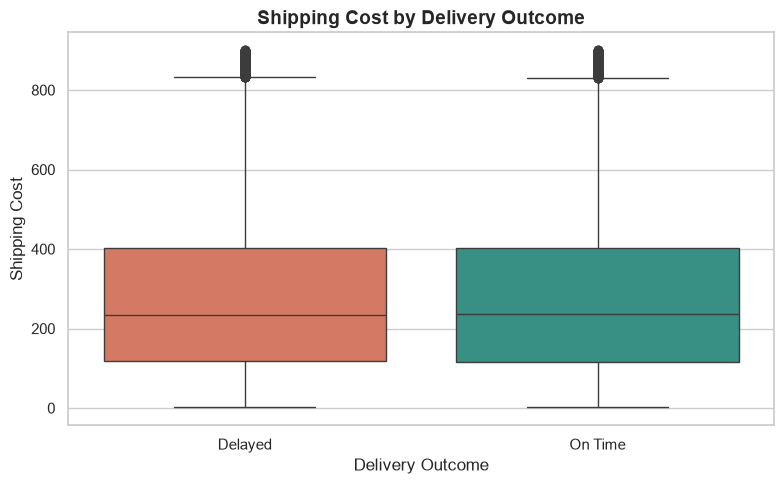

In [68]:
# Calculate shipping-cost statistics by delivery status
shipping_cost_summary = (
    df_eda.groupby("Delivery_Status")["Shipping_Cost"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .reindex(["Delayed", "On Time"])
)

# Rename columns for readability
shipping_cost_summary.columns = [
    "Record_Count",
    "Mean",
    "Median",
    "Standard_Deviation",
    "Minimum",
    "Maximum",
]

# Display the summary table
display(shipping_cost_summary.round(2))

# Create a boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Delivery_Status",
    y="Shipping_Cost",
    hue="Delivery_Status",
    order=["Delayed", "On Time"],
    palette=delivery_palette,
    legend=False,
)

plt.title(
    "Shipping Cost by Delivery Outcome",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Delivery Outcome")
plt.ylabel("Shipping Cost")
plt.tight_layout()

# Save the chart
shipping_cost_outcome_chart_path = Path(
    "../outputs/figures/shipping_cost_by_delivery_outcome.png"
)

if not shipping_cost_outcome_chart_path.parent.exists():
    shipping_cost_outcome_chart_path = Path(
        "outputs/figures/shipping_cost_by_delivery_outcome.png"
    )

shipping_cost_outcome_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    shipping_cost_outcome_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {shipping_cost_outcome_chart_path}")

plt.show()

#### Observation – Shipping Cost by Delivery Outcome

Shipping cost is very similar for delayed and on-time deliveries.

Delayed orders have a mean shipping cost of **283.33** and a median of **233.15**. 
On-time orders have a slightly higher mean of **287.80** and a median of **237.60**.

The standard deviation, minimum, maximum, and overall spread are also very similar 
for both groups. The boxplot shows a large amount of overlap between delayed and 
on-time deliveries.

Both groups contain several high shipping-cost values above the upper boxplot 
whiskers. These values appear in both delivery classes, so they should not be 
treated as errors or removed automatically.

This suggests that `Shipping_Cost` does not clearly separate delayed and on-time 
deliveries when examined by itself. It may still be useful when combined with other 
variables, but it is unlikely to be a strong standalone predictor.

### 8.14 Correlation of Numerical Variables with Delivery Outcome

Correlation analysis was used to measure the direction and strength of the linear 
relationship between the numerical candidate predictors and 
`Delivery_Time_OnTime`.

The numerical variables were ranked using the absolute value of their correlation 
with the target. A larger absolute value shows a stronger linear relationship, 
while a value close to zero shows little linear relationship.

,Correlation,Absolute_Correlation
Lead_Time_Days,-0.589,0.589
Port_Congestion_Index,-0.382,0.382
Product_Price,-0.015,0.015
Weather_Index,-0.014,0.014
Competitor_Price,-0.014,0.014
Historical_Sales,0.012,0.012
Year,0.011,0.011
Carbon_Emission,0.010,0.010
Fuel_Cost_Index,-0.009,0.009
Website_Traffic,-0.009,0.009


Chart saved to: ..\outputs\figures\target_correlation_ranking.png


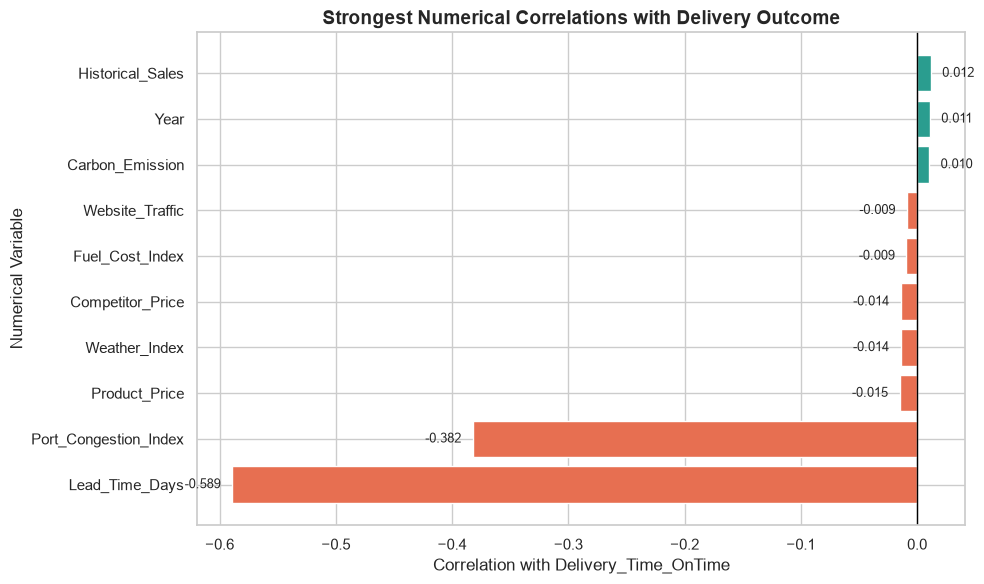

In [69]:
# Select numerical candidate independent variables
numeric_candidate_variables = [
    column
    for column in independent_variables
    if pd.api.types.is_numeric_dtype(df_eda[column])
]

# Calculate correlations with the delivery target
target_correlations = (
    df_eda[
        numeric_candidate_variables
        + [target_column]
    ]
    .corr(numeric_only=True)[target_column]
    .drop(target_column)
)

# Create and rank the correlation summary
correlation_summary = (
    target_correlations
    .rename("Correlation")
    .to_frame()
)

correlation_summary["Absolute_Correlation"] = (
    correlation_summary["Correlation"].abs()
)

correlation_summary = (
    correlation_summary
    .sort_values(
        "Absolute_Correlation",
        ascending=False,
    )
)

# Display the 15 strongest correlations
display(correlation_summary.head(15).round(3))

# Prepare the 10 strongest correlations for visualization
top_correlations = (
    correlation_summary
    .head(10)
    .sort_values("Correlation")
)

# Use different colors for positive and negative relationships
bar_colors = [
    "#2A9D8F" if value >= 0 else "#E76F51"
    for value in top_correlations["Correlation"]
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_correlations.index,
    top_correlations["Correlation"],
    color=bar_colors,
    edgecolor="white",
)

plt.axvline(
    0,
    color="black",
    linewidth=1,
)

plt.title(
    "Strongest Numerical Correlations with Delivery Outcome",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Correlation with Delivery_Time_OnTime")
plt.ylabel("Numerical Variable")

# Add correlation values
for bar, value in zip(
    bars,
    top_correlations["Correlation"],
):
    horizontal_alignment = (
        "left" if value >= 0 else "right"
    )

    offset = 0.01 if value >= 0 else -0.01

    plt.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha=horizontal_alignment,
        fontsize=9,
    )

plt.tight_layout()

# Save the chart
correlation_chart_path = Path(
    "../outputs/figures/target_correlation_ranking.png"
)

if not correlation_chart_path.parent.exists():
    correlation_chart_path = Path(
        "outputs/figures/target_correlation_ranking.png"
    )

correlation_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    correlation_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {correlation_chart_path}")

plt.show()

#### Observation – Correlation with Delivery Outcome

`Lead_Time_Days` has the strongest correlation with the delivery outcome, with a 
correlation of **-0.589**. Since the target value `1` represents an on-time 
delivery, this negative relationship means that longer lead times are associated 
with a lower chance of on-time delivery.

`Port_Congestion_Index` has the second strongest correlation at **-0.382**. This 
also shows that higher port-congestion values are associated with fewer on-time 
deliveries.

The remaining numerical variables have correlations close to zero. For example, 
`Product_Price`, `Weather_Index`, `Competitor_Price`, `Shipping_Cost`, and 
`Distance_to_Customer` show only very weak linear relationships with the delivery 
outcome when examined individually.

These results support the earlier boxplot findings for lead time and port 
congestion. However, correlation only measures linear relationships. Variables 
with weak individual correlations may still become useful when combined with 
other variables or used in nonlinear machine learning models.

`Lead_Time_Days` will also be reviewed carefully before modeling to confirm that 
it is known before the final delivery outcome and does not create data leakage.

### 8.15 Correlation Heatmap of Selected Numerical Variables

A correlation heatmap was created to examine the relationships among the numerical 
variables that showed the strongest relationship with the delivery outcome.

The heatmap helps identify whether any predictors are strongly related to each 
other and whether they may contain similar information.

,Delivery_Time_OnTime,Lead_Time_Days,Port_Congestion_Index,Product_Price,Weather_Index,Competitor_Price,Historical_Sales,Carbon_Emission,Fuel_Cost_Index,Shipping_Cost
Delivery_Time_OnTime,1.000,-0.589,-0.382,-0.015,-0.014,-0.014,0.012,0.010,-0.009,0.009
Lead_Time_Days,-0.589,1.000,0.012,0.013,0.000,0.012,-0.015,0.002,0.007,-0.001
Port_Congestion_Index,-0.382,0.012,1.000,-0.008,0.013,-0.009,-0.001,-0.013,0.002,-0.014
Product_Price,-0.015,0.013,-0.008,1.000,-0.003,0.993,0.005,0.000,-0.001,0.002
Weather_Index,-0.014,0.000,0.013,-0.003,1.000,-0.003,-0.009,-0.001,-0.001,-0.001
Competitor_Price,-0.014,0.012,-0.009,0.993,-0.003,1.000,0.005,-0.001,0.001,0.001
Historical_Sales,0.012,-0.015,-0.001,0.005,-0.009,0.005,1.000,-0.004,-0.013,-0.002
Carbon_Emission,0.010,0.002,-0.013,0.000,-0.001,-0.001,-0.004,1.000,0.006,0.902
Fuel_Cost_Index,-0.009,0.007,0.002,-0.001,-0.001,0.001,-0.013,0.006,1.000,0.007
Shipping_Cost,0.009,-0.001,-0.014,0.002,-0.001,0.001,-0.002,0.902,0.007,1.000


Chart saved to: ..\outputs\figures\correlation_heatmap.png


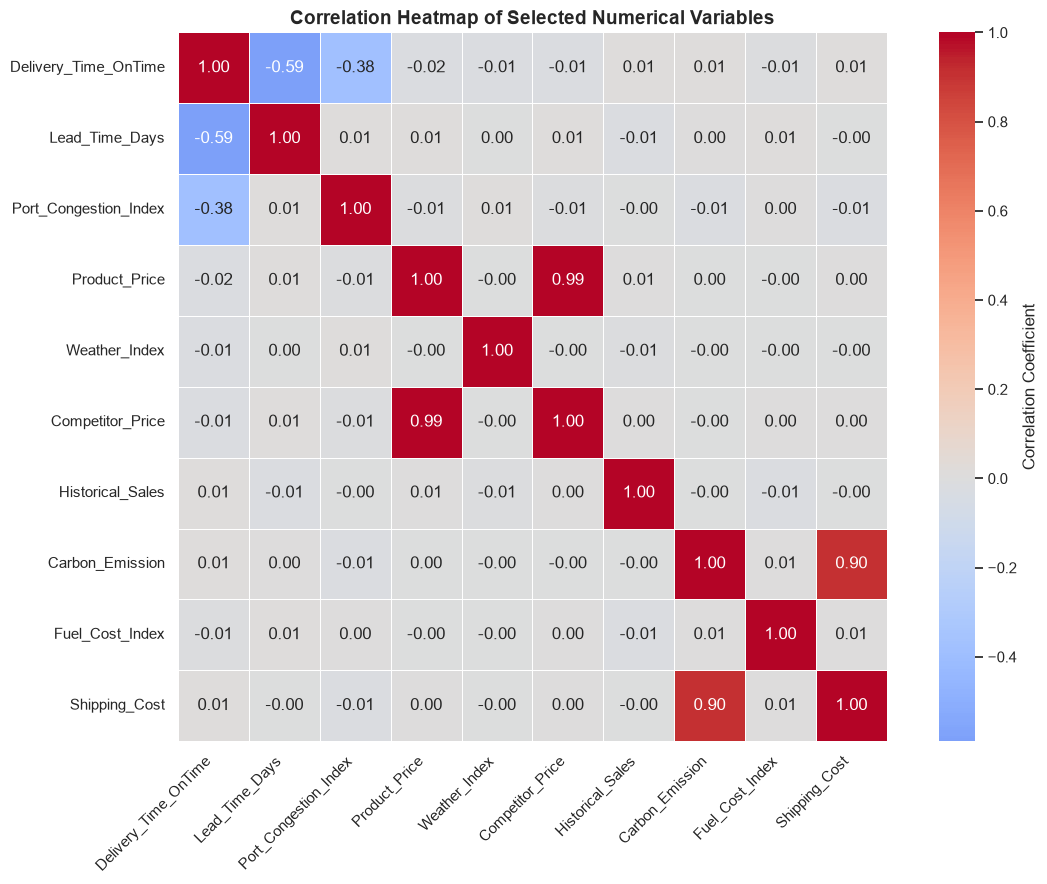

In [70]:
# Select numerical variables for the correlation heatmap
heatmap_features = [
    "Delivery_Time_OnTime",
    "Lead_Time_Days",
    "Port_Congestion_Index",
    "Product_Price",
    "Weather_Index",
    "Competitor_Price",
    "Historical_Sales",
    "Carbon_Emission",
    "Fuel_Cost_Index",
    "Shipping_Cost",
]

# Calculate the correlation matrix
heatmap_correlation_matrix = (
    df_eda[heatmap_features]
    .corr(numeric_only=True)
)

# Display the correlation matrix
display(heatmap_correlation_matrix.round(3))

# Create the heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    heatmap_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Correlation Coefficient",
    },
)

plt.title(
    "Correlation Heatmap of Selected Numerical Variables",
    fontsize=14,
    fontweight="bold",
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Save the chart
heatmap_chart_path = Path(
    "../outputs/figures/correlation_heatmap.png"
)

if not heatmap_chart_path.parent.exists():
    heatmap_chart_path = Path(
        "outputs/figures/correlation_heatmap.png"
    )

heatmap_chart_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.savefig(
    heatmap_chart_path,
    dpi=300,
    bbox_inches="tight",
)

print(f"Chart saved to: {heatmap_chart_path}")

plt.show()

#### Observation – Correlation Heatmap

The heatmap confirms that `Lead_Time_Days` and `Port_Congestion_Index` have the 
strongest relationships with the delivery outcome.

`Lead_Time_Days` has a correlation of **-0.589** with 
`Delivery_Time_OnTime`, while `Port_Congestion_Index` has a correlation of 
**-0.382**. Since the target value `1` represents an on-time delivery, these 
negative values show that higher lead time and higher port congestion are 
associated with a lower chance of on-time delivery.

The heatmap also shows two very strong relationships between predictor variables. 
`Product_Price` and `Competitor_Price` have a correlation of **0.993**, which means 
they contain almost the same linear pattern. `Carbon_Emission` and `Shipping_Cost` 
also have a strong positive correlation of **0.902**.

These high correlations may create multicollinearity or duplicate information in 
some models. Therefore, these variable pairs should be reviewed during feature 
selection and model preparation.

Most of the remaining relationships are close to zero, showing that they have very 
weak linear relationships with one another. However, weak correlation does not mean 
a variable is automatically unimportant, because nonlinear models may still find 
useful patterns.

### 8.16 Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method was used to identify possible outliers in 
selected numerical variables.

For each variable, the first quartile, third quartile, IQR, lower limit, and upper 
limit were calculated. Values outside these limits were counted as possible 
outliers.

These values are not automatically treated as errors because unusual observations 
may represent real supply-chain conditions.

In [71]:
# Select numerical variables for outlier analysis
outlier_features = [
    "Lead_Time_Days",
    "Supplier_Reliability",
    "Port_Congestion_Index",
    "Shipping_Cost",
    "Carbon_Emission",
]

outlier_results = []

# Calculate IQR limits and possible outliers
for feature in outlier_features:
    first_quartile = df_eda[feature].quantile(0.25)
    third_quartile = df_eda[feature].quantile(0.75)

    interquartile_range = (
        third_quartile - first_quartile
    )

    lower_limit = (
        first_quartile
        - 1.5 * interquartile_range
    )

    upper_limit = (
        third_quartile
        + 1.5 * interquartile_range
    )

    outlier_mask = (
        (df_eda[feature] < lower_limit)
        | (df_eda[feature] > upper_limit)
    )

    outlier_count = outlier_mask.sum()

    outlier_results.append({
        "Variable": feature,
        "Q1": first_quartile,
        "Q3": third_quartile,
        "IQR": interquartile_range,
        "Lower_Limit": lower_limit,
        "Upper_Limit": upper_limit,
        "Possible_Outliers": outlier_count,
        "Outlier_Percentage": (
            outlier_count
            / len(df_eda)
            * 100
        ),
    })

# Create the outlier summary table
outlier_summary = (
    pd.DataFrame(outlier_results)
    .sort_values(
        "Outlier_Percentage",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(outlier_summary.round(3))

,Variable,Q1,Q3,IQR,Lower_Limit,Upper_Limit,Possible_Outliers,Outlier_Percentage
0,Carbon_Emission,85.263,310.243,224.980,-252.208,647.713,1175,4.700
1,Shipping_Cost,117.038,402.885,285.847,-311.733,831.656,629,2.516
2,Lead_Time_Days,11.000,26.000,15.000,-11.500,48.500,0,0.000
3,Port_Congestion_Index,24.636,74.895,50.259,-50.753,150.284,0,0.000
4,Supplier_Reliability,77.429,92.526,15.097,54.783,115.172,0,0.000


#### Observation – Outlier Detection

The IQR method identified possible outliers only in `Carbon_Emission` and 
`Shipping_Cost`.

`Carbon_Emission` has **1,175 possible outliers**, which represents **4.70%** of 
the dataset. Values above **647.713** were identified as possible high-end outliers.

`Shipping_Cost` has **629 possible outliers**, which represents **2.516%** of the 
dataset. Values above **831.656** were identified as possible high-end outliers.

No possible outliers were identified for `Lead_Time_Days`, 
`Port_Congestion_Index`, or `Supplier_Reliability` using the IQR method.

These results match the earlier distribution charts, where `Carbon_Emission` and 
`Shipping_Cost` showed right-skewed patterns. However, the identified values will 
not be removed automatically because they may represent valid high-cost or 
high-emission supply-chain situations. Their effect will be reviewed during model 
development.

#### Observation – Outlier Detection

The IQR method identified possible outliers only in `Carbon_Emission` and 
`Shipping_Cost`.

`Carbon_Emission` has **1,175 possible outliers**, which represents **4.70%** of 
the dataset. Values above **647.713** were identified as possible high-end outliers.

`Shipping_Cost` has **629 possible outliers**, which represents **2.516%** of the 
dataset. Values above **831.656** were identified as possible high-end outliers.

No possible outliers were identified for `Lead_Time_Days`, 
`Port_Congestion_Index`, or `Supplier_Reliability` using the IQR method.

These results match the earlier distribution charts, where `Carbon_Emission` and 
`Shipping_Cost` showed right-skewed patterns. However, the identified values will 
not be removed automatically because they may represent valid high-cost or 
high-emission supply-chain situations. Their effect will be reviewed during model 
development.

### 8.17 EDA Summary and Key Learnings

The exploratory data analysis helped me understand the main patterns in the dataset 
before starting predictive modeling.

The target variable is clearly imbalanced. Delayed deliveries represent **77.11%** 
of the dataset, while on-time deliveries represent **22.89%**. Because of this, 
accuracy alone will not be enough to evaluate the machine learning models.

The product categories, shipping modes, regions, and customer segments are distributed 
fairly evenly. Country-level order counts are less balanced, but the on-time delivery 
rates still remain within a relatively small range across countries.

The categorical comparisons showed only small differences in delivery performance. 
For example, on-time rates were similar across shipping modes, regions, and product 
categories. This suggests that these variables may not strongly predict delivery 
outcome when examined individually.

The clearest numerical differences were found in `Lead_Time_Days` and 
`Port_Congestion_Index`. Delayed orders had much higher lead times and port-congestion 
levels than on-time orders. These variables also had the strongest correlations with 
the delivery outcome, at **-0.589** and **-0.382**, respectively.

`Supplier_Reliability` and `Shipping_Cost` showed very similar distributions for 
delayed and on-time deliveries. Therefore, they may not be strong predictors when 
used alone, although they may still contribute when combined with other variables.

The correlation heatmap also showed very strong relationships between 
`Product_Price` and `Competitor_Price`, and between `Carbon_Emission` and 
`Shipping_Cost`. These relationships will need to be reviewed during feature 
selection because they may provide overlapping information.

The IQR analysis identified possible outliers in `Carbon_Emission` and 
`Shipping_Cost`. These values were not removed because they may represent valid 
high-cost or high-emission supply-chain situations.

One important lesson from this phase is that EDA should not be used only to create 
charts. It helps identify class imbalance, possible data leakage, overlapping 
features, skewed variables, outliers, and the variables that may be most useful for 
prediction.

Before modeling, the meaning of `Lead_Time_Days` will be reviewed carefully. If it 
is known before shipment, it can be used as a predictor. If it is calculated only 
after delivery, it may cause data leakage and should be excluded.

Overall, the EDA phase provided a clear direction for preprocessing, feature 
selection, class-imbalance handling, model evaluation, and later SHAP-based 
explainability.